##### Data

In [15]:
!GIT_LFS_SKIP_SMUDGE=1 git clone https://huggingface.co/datasets/prefixsliding/evals

fatal: destination path 'evals' already exists and is not an empty directory.


In [16]:
import json

# Prefix Sliding
with open('evals/Qwen3-1.7B-SW/swf2048/toks524288/aime25_nofigures_tok524288_agg64/results_2025-10-23T04-26-30.125866.json', 'r') as f:
    qwen_swf2048 = json.load(f)

with open('evals/Qwen3-1.7B-SW/swf2048/toks524288/openai_math_tok524288_agg64/results_2025-10-23T07-25-30.266123.json', 'r') as f:
    qwen_swf2048_math = json.load(f)


with open('evals/Qwen3-1.7B-SW/swf4096/toks524288/aime25_nofigures_tok524288_agg64/results_2025-10-23T02-47-34.796144.json', 'r') as f:
    qwen_swf4096 = json.load(f)

with open('evals/Qwen3-1.7B-SW/swf4096/toks524288/openai_math_tok524288_agg64/results_2025-10-23T04-19-10.134229.json', 'r') as f:
    qwen_swf4096_math = json.load(f)

with open('evals/Qwen3-1.7B-SW/swf4096/toks524288/gpqa_diamond_openai_tok524288_agg64/results_2025-10-23T06-01-45.057871.json', 'r') as f:
    qwen_swf4096_gpqa = json.load(f)


with open('evals/Qwen3-1.7B-SW/swf8192/toks524288/aime25_nofigures_tok524288_agg64/results_2025-10-23T04-50-41.243266.json', 'r') as f:
    qwen_swf8192 = json.load(f)

with open('evals/Qwen3-1.7B-SW/swf8192/toks524288/openai_math_tok524288_agg64/results_2025-10-23T06-58-40.642180.json', 'r') as f:
    qwen_swf8192_math = json.load(f)

with open('evals/Qwen3-1.7B-SW/swf8192/toks524288/gpqa_diamond_openai_tok524288_agg64/results_2025-10-23T08-05-06.713441.json', 'r') as f:
    qwen_swf8192_gpqa = json.load(f)


with open('evals/Qwen3-1.7B-SW/swf16384/toks524288/aime25_nofigures_tok524288_agg64/results_2025-10-23T15-59-10.245293.json', 'r') as f:
    qwen_swf16384 = json.load(f)

with open('evals/Qwen3-1.7B-SW/swf16384/toks524288/openai_math_tok524288_agg64/results_2025-10-23T18-08-31.687190.json', 'r') as f:
    qwen_swf16384_math = json.load(f)

with open('evals/Qwen3-1.7B-SW/swf16384/toks524288/gpqa_diamond_openai_tok524288_agg64/results_2025-10-23T20-26-20.168921.json', 'r') as f:
    qwen_swf16384_gpqa = json.load(f)

# Full Attn
with open('evals/Qwen3-1.7B/results_2025-10-05T02-20-11.454987.json', 'r') as f:
    qwen_full = json.load(f)

with open('evals/Qwen3-1.7B/results_2025-10-08T05-56-34.870139.json', 'r') as f:
    qwen_full_gpqa = json.load(f)

with open('evals/Qwen3-1.7B/results_2025-10-08T07-50-45.964822.json', 'r') as f:
    qwen_full_math = json.load(f)


# Ablations
with open('evals/Qwen3-1.7B-LASTK/w4096k256/toks262144/results_concatted_tok262144.json', 'r') as f:
    qwen_w4096k256 = json.load(f)

with open('evals/Qwen3-1.7B-SUMM/w4096s256context/toks262144/results_concatted_tok262144.json', 'r') as f:
    qwen_w4096s256 = json.load(f)

with open('evals/Qwen3-1.7B-SW/sw4096/toks524288/aime25_nofigures_tok524288_agg64/results_2025-11-12T11-33-16.897054.json', 'r') as f:
    qwen_sw4096 = json.load(f)


# Health
with open('evals/Qwen3-1.7B-SW/swf2048/toks262144/results_2025-12-06T06-05-47.523873.json', 'r') as f:
    qwen_swf2048_health = json.load(f)

with open('evals/Qwen3-1.7B/results_2025-12-04T02-17-59.726740.json', 'r') as f:
    qwen_full_health = json.load(f)

# Speed
with open('evals/results.json', 'r') as f:
    results = json.load(f)

In [17]:
OUR_COLOR = "#0077B6"
FULL_ATTN_COLOR = "#E90909"

In [18]:
# Fill missing results

for sw in [2048, 4096, 8192, 16384]:
  results['results']['Qwen/Qwen3-1.7B']['1024']['SW'][str(sw)] = results['results']['Qwen/Qwen3-1.7B']['1024']['Full']
  results['results']['Qwen/Qwen3-1.7B']['2048']['SW'][str(sw)] = results['results']['Qwen/Qwen3-1.7B']['2048']['Full']
  if sw != 2048:
    results['results']['Qwen/Qwen3-1.7B']['4096']['SW'][str(sw)] = results['results']['Qwen/Qwen3-1.7B']['4096']['Full']
    if sw != 4096:
      results['results']['Qwen/Qwen3-1.7B']['8192']['SW'][str(sw)] = results['results']['Qwen/Qwen3-1.7B']['8192']['Full']
      if sw != 8192:
        results['results']['Qwen/Qwen3-1.7B']['16384']['SW'][str(sw)] = results['results']['Qwen/Qwen3-1.7B']['8192']['Full']

for sw in [4096]:
  results['results']['Qwen/Qwen3-1.7B']['1024']['SWR'] = {}
  results['results']['Qwen/Qwen3-1.7B']['2048']['SWR'] = {}
  results['results']['Qwen/Qwen3-1.7B']['4096']['SWR'] = {}
  results['results']['Qwen/Qwen3-1.7B']['1024']['SWR'][str(sw)] = results['results']['Qwen/Qwen3-1.7B']['1024']['Full']
  results['results']['Qwen/Qwen3-1.7B']['2048']['SWR'][str(sw)] = results['results']['Qwen/Qwen3-1.7B']['2048']['Full']
  results['results']['Qwen/Qwen3-1.7B']['4096']['SWR'][str(sw)] = results['results']['Qwen/Qwen3-1.7B']['4096']['Full']

  results['results']['Qwen/Qwen3-1.7B']['1024']['Lastk'] = {}
  results['results']['Qwen/Qwen3-1.7B']['2048']['Lastk'] = {}
  results['results']['Qwen/Qwen3-1.7B']['4096']['Lastk'] = {}
  results['results']['Qwen/Qwen3-1.7B']['1024']['Lastk'][str(sw)] = results['results']['Qwen/Qwen3-1.7B']['1024']['Full']
  results['results']['Qwen/Qwen3-1.7B']['2048']['Lastk'][str(sw)] = results['results']['Qwen/Qwen3-1.7B']['2048']['Full']
  results['results']['Qwen/Qwen3-1.7B']['4096']['Lastk'][str(sw)] = results['results']['Qwen/Qwen3-1.7B']['4096']['Full']

  results['results']['Qwen/Qwen3-1.7B']['1024']['Summary'] = {}
  results['results']['Qwen/Qwen3-1.7B']['2048']['Summary'] = {}
  results['results']['Qwen/Qwen3-1.7B']['4096']['Summary'] = {}
  results['results']['Qwen/Qwen3-1.7B']['1024']['Summary'][str(sw)] = results['results']['Qwen/Qwen3-1.7B']['1024']['Full']
  results['results']['Qwen/Qwen3-1.7B']['2048']['Summary'][str(sw)] = results['results']['Qwen/Qwen3-1.7B']['2048']['Full']
  results['results']['Qwen/Qwen3-1.7B']['4096']['Summary'][str(sw)] = results['results']['Qwen/Qwen3-1.7B']['4096']['Full']


results['results']['Qwen/Qwen3-1.7B']['262144']['SW']['16384'] = results['results']['Qwen/Qwen3-1.7B']['131072']['SW']['16384']
results['results']['Qwen/Qwen3-1.7B']['262144']['SW']['8192'] = results['results']['Qwen/Qwen3-1.7B']['131072']['SW']['8192']
results['results']['Qwen/Qwen3-1.7B']['262144']['SW']['4096'] = results['results']['Qwen/Qwen3-1.7B']['131072']['SW']['4096']

results['results']['Qwen/Qwen3-1.7B']['524288']['SW']['16384'] = results['results']['Qwen/Qwen3-1.7B']['131072']['SW']['16384']
results['results']['Qwen/Qwen3-1.7B']['524288']['SW']['8192'] = results['results']['Qwen/Qwen3-1.7B']['131072']['SW']['8192']

# Read from logs
results['results']['Qwen/Qwen3-1.7B']['262144']['SW']['4096'] = 4950
results['results']['Qwen/Qwen3-1.7B']['524288']['SWR'] = {}
results['results']['Qwen/Qwen3-1.7B']['524288']['SWR']['4096'] = 4940

results['results']['Qwen/Qwen3-1.7B']['262144']['Lastk'] = {}
results['results']['Qwen/Qwen3-1.7B']['262144']['Lastk']['4096'] = 8150

results['results']['Qwen/Qwen3-1.7B']['262144']['Summary'] = {}
results['results']['Qwen/Qwen3-1.7B']['262144']['Summary']['4096'] = 3100

results['results']['Qwen/Qwen3-1.7B']['262144']['Full'] = 230
results['results']['Qwen/Qwen3-1.7B']['524288']['Full'] = 120

In [19]:
def dedupe_pair(a, b):
    seen = set()
    A, B = [], []
    for x, y in zip(a, b):
        if x not in seen:
            seen.add(x)
            A.append(x); B.append(y)
    return A, B

##### Plot: LCB

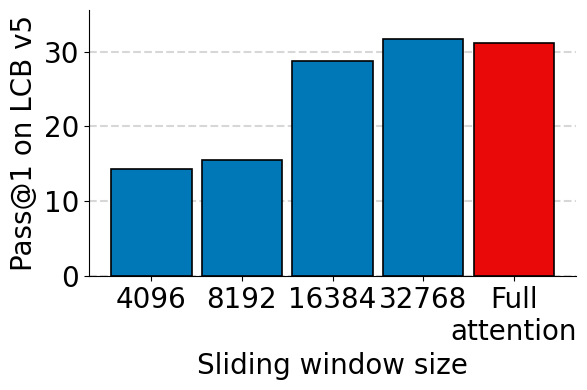

In [20]:
import numpy as np
import matplotlib.pyplot as plt

FONTSIZE = 20

fig, ax = plt.subplots(figsize=(6, 4), facecolor="w")

SW_TO_SCORE = {
    4096: 0.1437125748502994 * 100,
    8192: 0.15568862275449102 * 100,
    16384: 0.2874251497005988 * 100,
    32768: 0.31736526946107785 * 100,
    "Full\nattention": 0.31137724550898205 * 100,
}

labels = list(SW_TO_SCORE.keys())
scores = list(SW_TO_SCORE.values())
x = np.arange(len(labels))

# simple, clean colors
# colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(labels)))
OUR_COLOR = "#0077B6"
FULL_ATTN_COLOR = "#E90909"
colors = [OUR_COLOR, OUR_COLOR, OUR_COLOR, OUR_COLOR, FULL_ATTN_COLOR]

x = np.arange(len(labels)) * 0.45
ax.bar(x, scores, color=colors, width=0.4, zorder=3, linewidth=1.2, edgecolor="black")
# labels & ticks
ax.set_xlabel("Sliding window size", fontsize=FONTSIZE)
ax.set_ylabel("Pass@1 on LCB v5", fontsize=FONTSIZE)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=FONTSIZE)
ax.tick_params(axis="y", labelsize=FONTSIZE)

# light grid for readability
ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0, linewidth=1.5)
ax.set_ylim(0, max(scores) * 1.12)

# remove top/right spines for a clean look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("lcb.pdf", bbox_inches="tight")
plt.show()

##### LCB example

In [21]:
exx = [
            "<think>\nOkay, let's see. I need to find the maximum number of operations where each operation is removing a character from the source string, but the pattern remains a subsequence after each removal. The targetIndices are the indices that can be removed, and they are sorted. \n\nSo the problem is about figuring out how many characters we can remove from the source, given that after each removal, the pattern remains a subsequence. \n\nFirst, let's think about the constraints. The targetIndices are sorted, which is important. Also, the pattern is a subsequence of the source. \n\nThe key here is that each time we remove a character from targetIndices, we need to ensure that the pattern remains a subsequence. So, for each possible removal, we have to check if the pattern is still a subsequence after that removal. \n\nBut checking all possibilities naively would be too slow, especially since the source can be up to 3000 characters. So we need an efficient way to find the maximum number of removals.\n\nHmm. Let's think about the problem in terms of binary search. Because the maximum number of operations is something that can be determined by checking if it's possible to remove k elements, and we can binary search on k. \n\nBut how do we check if it's possible to remove k elements? \n\nAlternatively, maybe we can model this as a problem where we need to find the maximum number of elements that can be removed from the targetIndices, such that the pattern remains a subsequence. \n\nWait, but the targetIndices are the indices that can be removed. So, for each removal, the index must be in targetIndices. But when you remove an index, the other indices remain. So the problem is that after removing some indices from targetIndices, the pattern must still be a subsequence of the modified source. \n\nBut how do we model this? \n\nLet me think. The process of removing elements is such that after each removal, the pattern must still be a subsequence. So, the order in which we remove the elements matters. \n\nBut since the targetIndices are sorted, perhaps we can process them in a certain way. For example, if we can remove elements in a way that allows the pattern to remain a subsequence. \n\nWait, but the problem is that when we remove a character, it's possible that the pattern is still a subsequence. So the challenge is to find the maximum number of elements we can remove from the targetIndices, such that the pattern remains a subsequence after each removal. \n\nSo the idea is that we need to select a subset of targetIndices (some of them) to remove, such that after removing them, the pattern is still a subsequence. And we want the maximum size of such a subset. \n\nBut how do we find this subset?\n\nLet me think of the problem as follows: the maximum number of operations is the maximum number of elements we can remove from targetIndices, such that the pattern remains a subsequence after each removal. \n\nSo, the problem is similar to selecting a subset of the targetIndices, where the pattern is still a subsequence of the source after removing those elements. \n\nBut how do we check if a subset of elements can be removed? \n\nOne approach is to model this as a problem where we want to find the maximum number of elements that can be removed, which is equivalent to finding the maximum number of elements that can be removed such that the pattern is still a subsequence. \n\nBut how to check if a certain number of elements can be removed? \n\nLet me think of binary search. Let's say we want to find the maximum k such that there exists a subset of k elements from targetIndices, such that after removing those elements, the pattern is still a subsequence. \n\nBut how do we check for a given k whether it's possible? \n\nAlternatively, perhaps the problem can be approached by considering that the elements that can be removed must not interfere with the pattern. So, the elements that are removed must not be in positions that are necessary for the pattern to be a subsequence. \n\nBut how to model this? \n\nAnother thought: when we remove elements, the pattern must still be a subsequence. So, for the pattern to remain a subsequence, the positions of the elements in the source must be such that the pattern can be found. \n\nLet me think of the process of checking if a certain number of elements can be removed. \n\nSuppose we have a list of targetIndices, sorted. Let's say we want to remove some elements from this list. The order in which we remove them matters. But since the targetIndices are sorted, perhaps we can process them in a way that allows us to check for the pattern. \n\nWait, but the problem is that when we remove elements, the pattern's subsequence is affected. So, for example, if we remove an element that is part of the pattern, then the pattern may not be a subsequence. \n\nBut how can we model this? \n\nLet me think of the problem in terms of the positions of the pattern. Let's say that the pattern is a subsequence of the source. So, the original source has the pattern as a subsequence. \n\nNow, when we remove some elements from the source (those in targetIndices), the pattern must still be a subsequence. \n\nSo, the problem reduces to selecting a subset of targetIndices to remove, such that after their removal, the pattern remains a subsequence. \n\nBut how do we find the maximum number of such elements? \n\nAn alternative approach is to model this as a greedy problem. For example, we can try to remove as many elements as possible from the targetIndices, but ensuring that the pattern remains a subsequence. \n\nBut how to do this greedily? \n\nLet's think of the problem as trying to remove elements that are not necessary for the pattern. For example, if we can remove elements that are not part of the pattern, then the pattern remains. \n\nBut how to find which elements can be removed. \n\nAnother idea: since the pattern is a subsequence of the source, and we can remove elements from the targetIndices, the elements that can be removed are those that are not in the pattern. \n\nWait, but that's not necessarily true. For example, if the pattern is \"aba\", and the source is \"abbaa\". The pattern is a subsequence. If we remove the first 'a' (source[0]), then the pattern is \"ba\", which is a subsequence of the remaining string. But the pattern is still a subsequence. \n\nSo, the elements that are removed can be any in targetIndices, but the pattern must still be a subsequence. \n\nSo, the problem is to find the maximum number of elements in targetIndices that can be removed, such that after their removal, the pattern is still a subsequence. \n\nSo, the problem is similar to the problem of finding the maximum number of elements that can be removed from the targetIndices, such that the pattern is still a subsequence. \n\nNow, how to model this. \n\nLet me think of the following approach: \n\nWe can model this as a problem where we need to find the maximum number of elements that can be removed from the targetIndices, such that the pattern remains a subsequence. \n\nThis seems like a problem that can be solved with binary search. Let's think about binary search on the number of operations. \n\nFor example, the maximum possible number of operations is the size of targetIndices. So, we can binary search between 0 and len(targetIndices). For each candidate k, we need to check if it's possible to remove k elements from targetIndices such that the pattern remains a subsequence. \n\nBut how to check this. \n\nSo, for a given k, how to check if there exists a subset of k elements from targetIndices such that after removing them, the pattern is still a subsequence. \n\nBut how to check that? \n\nOne way to think is that, for the pattern to remain a subsequence, the elements that are removed must not interfere with the pattern's subsequence. \n\nBut how to model this. \n\nAn alternative approach is to model the problem as follows: \n\nWe can greedily remove elements from the targetIndices that are not needed for the pattern. \n\nBut how? \n\nLet me think of the following approach: \n\nWe can process the targetIndices in order, and for each element, check if it's possible to remove it, given that the pattern is still a subsequence. \n\nBut since the pattern is a subsequence, and we need to remove elements, perhaps we can model this as a greedy selection. \n\nLet me think of the following steps. \n\nWe can first pre-process the targetIndices. Let's say that we have a list of indices that can be removed. We need to choose which ones to remove. \n\nBut how to check if the pattern remains a subsequence after removing some elements. \n\nAn alternative idea is to model the problem as follows: \n\nWe can model the problem as a problem where we need to find the maximum number of elements that can be removed, which is equivalent to the maximum number of elements that can be removed from the targetIndices such that the pattern remains a subsequence. \n\nTo check if a certain number of elements can be removed, we can use a greedy approach. For example, we can try to remove elements from the targetIndices in a way that they are not part of the pattern. \n\nBut how? \n\nLet me think of the following approach. \n\nWe can use a greedy method where we try to remove elements from the targetIndices in a way that they are not part of the pattern. \n\nBut perhaps the best way is to find the positions in the source where the pattern can be found, and then see which elements can be removed. \n\nWait, here's an idea inspired by the problem of finding the maximum number of elements that can be removed from a list such that the pattern remains a subsequence. \n\nLet me think of the problem as follows: \n\nWe can first find the positions of the pattern in the source. Then, for the elements that are not in the pattern, we can remove them. But this is not straightforward. \n\nAlternatively, the problem is similar to the problem where we have to find the maximum number of elements that can be removed from the source, such that the pattern remains a subsequence. \n\nBut the problem is that the elements that are removed are in the targetIndices. \n\nSo, here's an idea: \n\nWe can model the problem as follows. Let's consider that the targetIndices are sorted. We can process them in order, and for each element, decide whether to remove it or not, based on whether it's necessary for the pattern to remain a subsequence. \n\nBut how to do this. \n\nLet me think of the following approach. \n\nWe can use a greedy algorithm where we try to remove elements from the targetIndices that are not part of the pattern. \n\nBut how to determine which elements are part of the pattern. \n\nAlternatively, here's a possible approach: \n\nWe can use a binary search on the number of elements to remove (k). For each k, we need to check if there exists a subset of k elements from targetIndices such that after removing them, the pattern remains a subsequence. \n\nTo check this, we can use a greedy approach. \n\nLet me think of the following steps for checking a given k:\n\n1. We need to select k elements from targetIndices to remove. \n\n2. The remaining elements (those not removed) must be such that the pattern is a subsequence. \n\nBut how to check that. \n\nAlternatively, the problem can be viewed as: after removing some elements from targetIndices, the pattern must still be a subsequence. \n\nSo, the key is to find a subset of elements to remove such that the pattern is still a subsequence. \n\nBut how to find this subset. \n\nAn alternative approach is to model this as a problem of finding the maximum number of elements that can be removed, which is equivalent to the maximum number of elements that can be removed from the targetIndices without breaking the pattern. \n\nBut how to model this. \n\nLet me think of the problem as follows: \n\nSuppose we have a list of targetIndices, sorted. We can process them in order, and for each element, decide whether to remove it or not. \n\nWe can use a greedy approach where we try to remove elements that are not needed for the pattern. \n\nFor example, when processing the targetIndices in order, we can check if the current element is part of the pattern. If not, we can remove it. But how to check this. \n\nBut this approach may not be correct. \n\nAlternatively, here's a way to think about it. \n\nWe can first find the positions of the pattern in the source. Then, the elements that are not in the pattern can be removed. However, the problem is that the pattern is a subsequence, so the elements that are not in the pattern can be removed. \n\nBut this is not necessarily the case. For example, if the pattern is \"aba\" and the source is \"abbaa\", then the pattern is a subsequence. If we remove the first 'a' (source[0]), the pattern becomes \"ba\", which is a subsequence. But the second 'a' (source[3]) is not part of the pattern. So, in this case, the pattern is still a subsequence. \n\nSo, the elements that are not in the pattern can be removed, but the elements that are in the pattern may be removed as long as they are not in the way that the pattern is broken. \n\nBut how to model this. \n\nAnother idea: the elements that can be removed are those that are not in the pattern's positions. Wait, no. Because the pattern is a subsequence, and when you remove elements, the pattern must still be a subsequence. \n\nSo, for example, if the pattern is \"aba\", and the source is \"abbaa\", then the pattern is a subsequence. If you remove the first 'a' (source[0]), then the pattern is \"ba\" which is a subsequence of the remaining source. \n\nSo, the elements that are removed can be any elements in the targetIndices, but the pattern must still be a subsequence. \n\nBut how to find which elements can be removed. \n\nLet me think of the problem as follows: \n\nWe need to find a subset of targetIndices to remove, such that the pattern remains a subsequence. \n\nThe key is that the elements that are removed must not be in positions that are necessary for the pattern. \n\nSo, for example, if the pattern is a subsequence, then the elements that are in the pattern must be present in the source. \n\nSo, the problem is to find the maximum number of elements in targetIndices that can be removed, such that the pattern is still a subsequence. \n\nBut how to check this. \n\nAn alternative approach is to model the problem as follows: \n\nWe can find the positions of the pattern in the source, and then find the positions in the source that are not in the pattern. But this is not directly helpful. \n\nAlternatively, let's think of the problem as a problem where the pattern must be a subsequence of the source after removing some elements. \n\nSo, the elements that are removed can be any elements in the targetIndices, but the pattern must be a subsequence. \n\nSo, the problem is similar to the problem of finding the maximum number of elements that can be removed from the targetIndices such that the pattern is still a subsequence. \n\nBut how to find this. \n\nLet me think of the following approach. \n\nWe can model the problem as a greedy selection of elements to remove. \n\nWe can process the targetIndices in order, and for each element, decide whether to remove it or not, based on whether it's necessary for the pattern to be a subsequence. \n\nBut how to do this. \n\nLet me think of the following steps: \n\nWe can first pre-process the pattern and the source. \n\nWe can create a list of positions where the pattern is found in the source. \n\nBut how to do that. \n\nFor example, for the pattern, we can find the positions in the source where the pattern is a subsequence. \n\nBut since the pattern is already a subsequence of the source, we can find the positions of the pattern in the source. \n\nBut how to model the positions. \n\nAlternatively, let's think of the problem as follows: \n\nWe can use a greedy approach to remove elements from the targetIndices. \n\nWe can process the targetIndices in order. For each element, we check if removing it would break the pattern. If not, we remove it. \n\nBut how to check if removing it would break the pattern. \n\nThis is similar to the problem of finding the maximum number of elements that can be removed from the targetIndices, such that the pattern remains a subsequence. \n\nSo, here's an idea: \n\nWe can process the targetIndices in order, and for each element, check if it's possible to remove it. \n\nBut how to check if removing it would break the pattern. \n\nTo check this, we can simulate the pattern being a subsequence. \n\nFor example, we can have a pointer for the pattern. Initially, it's at 0. For each element in the source (excluding the ones that are removed), we check if the pattern is a subsequence. \n\nBut since the targetIndices are sorted, and we are processing them in order, perhaps we can do the following: \n\nWe can keep track of the current position in the pattern. For each element in the targetIndices, if it's not in the current pattern's position, then we can remove it. \n\nWait, but this is getting complicated. \n\nAlternatively, here's a possible approach inspired by the problem of finding the maximum number of elements that can be removed from the targetIndices such that the pattern remains a subsequence. \n\nLet me think of the following steps: \n\nWe can process the targetIndices in order. For each element, we check if removing it would allow the pattern to remain a subsequence. \n\nIf it's possible to remove it, then we remove it and proceed. \n\nBut how to check if it's possible. \n\nThe way to check this is to simulate the pattern being a subsequence, but with the current element not being removed. \n\nBut this seems computationally expensive. \n\nAlternatively, we can model the problem as follows: \n\nWe can simulate the process of checking whether the pattern is a subsequence of the source after removing some elements. \n\nBut since the elements to be removed are in the targetIndices, and they are sorted, perhaps we can use a greedy approach. \n\nLet me think of the following algorithm: \n\nWe can keep track of the positions in the source where the pattern is found. For each element in the targetIndices, we can try to remove it if it's not needed for the pattern. \n\nBut how to determine if it's needed. \n\nLet me think of the following approach. \n\nWe can have a pointer for the pattern. Initially, it's at 0. \n\nWe can process the targetIndices in order. For each index in targetIndices, we check if the current element is part of the pattern. If it is, then we need to check if removing it would allow the pattern to be a subsequence. \n\nBut this is not straightforward. \n\nAlternatively, here's a possible approach inspired by the problem of finding the maximum number of elements that can be removed from the targetIndices, such that the pattern remains a subsequence. \n\nWe can use a greedy approach where we remove elements from the targetIndices that are not necessary for the pattern. \n\nFor example, we can process the targetIndices in order. For each element, we check if it's possible to remove it. \n\nTo check this, we can simulate the pattern as a subsequence, but skipping the current element. \n\nBut how to do this. \n\nLet me think of the following steps. \n\nLet's have a function that, given a list of indices (the targetIndices), and a current position in the pattern, checks if the pattern can still be a subsequence after removing the elements in the list up to a certain point. \n\nBut this seems too vague. \n\nAlternatively, here's a possible way to model the problem. \n\nLet me think of the following steps: \n\nWe can first find the positions where the pattern occurs in the source. \n\nThen, we can find the positions in the source that are not in the pattern. \n\nBut this is not directly helpful. \n\nAnother idea: since the pattern is a subsequence of the source, the elements that are not part of the pattern can be removed. \n\nBut again, this is not directly applicable. \n\nAlternatively, the problem can be modeled as follows: \n\nWe need to find the maximum number of elements that can be removed from the targetIndices such that the pattern is still a subsequence. \n\nThis is equivalent to finding the maximum number of elements that can be removed from the targetIndices, such that the pattern is a subsequence of the source after removing them. \n\nSo, the problem is similar to the problem of finding the maximum number of elements that can be removed from a list (targetIndices) such that the pattern remains a subsequence. \n\nThis is similar to the problem where you have to remove elements from a list to make the pattern a subsequence. \n\nBut in this case, the elements to be removed are in a certain list (targetIndices), and we can remove any subset of them. \n\nSo, the maximum number of elements that can be removed is the maximum k such that there exists a subset of k elements from targetIndices where the pattern is a subsequence after removing them. \n\nNow, the problem is to find this maximum k. \n\nTo find this, we can use binary search. \n\nLet me think of the binary search approach. \n\nThe maximum possible k is len(targetIndices). The minimum is 0. \n\nFor a given k, we need to check whether there exists a subset of k elements from targetIndices such that after removing them, the pattern is a subsequence. \n\nBut how to check this. \n\nThe key is to find a subset of k elements to remove. \n\nTo check this, we can use a greedy approach. \n\nFor example, we can try to remove the elements in the targetIndices that are not needed for the pattern. \n\nLet me think of the following approach. \n\nWe can process the targetIndices in order, and for each element, we check if it's possible to remove it. \n\nTo check this, we can simulate the pattern as a subsequence. \n\nLet me think of the following steps: \n\nWe have a list of targetIndices, sorted. \n\nWe can create a list of the positions in the source where the pattern is a subsequence. \n\nBut how to do this. \n\nAlternatively, here's a way to model the problem. \n\nWe can simulate the pattern as a subsequence, and for each element in the targetIndices, we can decide whether to remove it or not. \n\nLet's think of the following algorithm: \n\nInitialize a variable 'i' to 0, which is the current position in the pattern. \n\nWe process the targetIndices in order. For each index in targetIndices, we check if the current element is part of the pattern. \n\nWait, perhaps not. \n\nAnother idea: \n\nWe can simulate the process of building the pattern. For each element in the source, we can check if it's part of the pattern. But since the elements to be removed are in the targetIndices, we need to check if the pattern can still be found in the source after removing those elements. \n\nBut how to do this. \n\nLet me think of the following approach. \n\nWe can create a list of the targetIndices in order. \n\nWe can process the elements in the targetIndices in order, and for each element, we check if it's possible to remove it. \n\nTo check this, we can simulate the pattern as a subsequence, but skipping the current element. \n\nFor example, we can have a pointer for the pattern. Initially, it's at 0. \n\nFor each element in the targetIndices, we can check if the current element is part of the pattern. If it is, then we can try to remove it, but we need to check if the pattern can still be found. \n\nBut how to do this. \n\nAlternatively, here's a possible way: \n\nWe can simulate the pattern as a subsequence, but for the elements in the targetIndices, we can skip them. \n\nFor example, we can have a list of the elements in the source, and for each element in the targetIndices, we can check if it's part of the pattern. \n\nBut this is not directly helpful. \n\nAlternatively, here's a way to think of it. \n\nWe can have a list of the positions in the source that are not in the targetIndices. But this is not directly helpful. \n\nAlternatively, here's a way to model the problem. \n\nWe can pre-process the source and the pattern. \n\nWe can find the positions in the source where the pattern is a subsequence. \n\nBut since the pattern is a subsequence of the source, we can find the positions of the pattern in the source. \n\nOnce we have that, we can find the positions in the source that are not in the targetIndices. \n\nBut again, not sure. \n\nAlternatively, think of the problem as follows: \n\nThe pattern must be a subsequence of the source after removing some elements. \n\nSo, for the pattern to be a subsequence, the elements in the pattern must appear in the source in the correct order. \n\nBut when we remove elements from the targetIndices, the elements that are not removed must be in the source. \n\nSo, the problem reduces to finding a subset of elements in the targetIndices to remove such that the pattern is a subsequence of the source after their removal. \n\nNow, to find the maximum number of elements that can be removed, we can use a greedy approach. \n\nLet me think of the following approach. \n\nWe can process the targetIndices in order. For each element, we check whether it's possible to remove it. \n\nTo check this, we can simulate the pattern being a subsequence, but skipping the current element. \n\nSo, for example, we can have a pointer for the pattern. Initially, it's at 0. \n\nWe process the targetIndices in order. For each element, we check if the current element is in the pattern. If it is, then we can remove it only if the pattern can still be found after removing it. \n\nBut this is not clear. \n\nAlternatively, the following approach: \n\nWe can simulate the pattern being a subsequence of the source, but for the elements in the targetIndices that are not removed. \n\nSo, for each element in the targetIndices, we can decide to remove it or not. \n\nBut how to decide. \n\nHere's a possible way to model this: \n\nWe can have a list of the source's characters, and a list of the targetIndices in order. \n\nWe can process the targetIndices in order, and for each element, we check if it's possible to remove it. \n\nTo check this, we can simulate the pattern being a subsequence, but with the current element being removed. \n\nIf the pattern is still a subsequence after removing the current element, then we can remove it. \n\nSo, the algorithm would be: \n\nInitialize a list of elements to be removed as empty. \n\nFor each index in targetIndices:\n\n   if removing this index does not break the pattern, add it to the list of removed elements. \n\nBut how to check if removing it breaks the pattern. \n\nTo check this, we can simulate the pattern as a subsequence, but with the current index removed. \n\nBut how to do this efficiently. \n\nLet me think of the following steps. \n\nWe can have a function that, given the source, pattern, and a list of indices to be removed, returns whether the pattern is a subsequence. \n\nBut this is not feasible for large n. \n\nBut since the targetIndices are sorted, and we are processing them in order, perhaps we can do this efficiently. \n\nLet me think of the following approach. \n\nWe can simulate the pattern as a subsequence. We can have a pointer for the pattern, and for each element in the source, we check if it's part of the pattern. \n\nBut when we remove an element, we need to check if it's part of the pattern. \n\nBut this is not straightforward. \n\nAlternatively, here's an idea inspired by the problem of finding the maximum number of elements that can be removed from the targetIndices such that the pattern remains a subsequence. \n\nLet me think of the following steps: \n\nWe can process the targetIndices in order, and for each element, we decide to remove it or not. \n\nTo decide whether to remove it, we can check if the pattern can still be a subsequence after removing it. \n\nTo check this, we can simulate the pattern as a subsequence, but skipping the current element. \n\nSo, for example, we can have a pointer for the pattern. \n\nInitially, the pattern pointer is at 0. \n\nFor each element in the source, we check if it's part of the pattern. \n\nBut if the current element is in the targetIndices, and we are considering removing it, then we need to check if the pattern can still be found. \n\nBut how to do this. \n\nLet me think of the following code. \n\nWe have a list of targetIndices, sorted. \n\nWe can process the elements in the targetIndices in order. \n\nWe can also have a list of the source's characters. \n\nWe can have a variable 'pattern_ptr' that tracks the current position in the pattern. \n\nFor each element in the targetIndices:\n\n   if the element is not in the current pattern, then we can remove it. \n\nBut this is not correct. \n\nAlternatively, for each element in the targetIndices, we can check if the current element is part of the pattern. \n\nBut how to check this. \n\nWait, the pattern is a subsequence of the source. So, the elements in the pattern are in the source. \n\nBut when we remove an element from the targetIndices, we have to make sure that the pattern is still a subsequence. \n\nSo, for example, if the current element is part of the pattern, then removing it could break the pattern. \n\nSo, the idea is to remove elements that are not needed for the pattern. \n\nBut how to find which elements are needed. \n\nHere's a possible approach. \n\nWe can simulate the process of building the pattern. We can have a pointer for the pattern, and for each element in the source, we check if it's part of the pattern. \n\nBut when we process the targetIndices, we can check if the current element is part of the pattern. \n\nBut this is not directly helpful. \n\nAlternatively, here's a way to think of it. \n\nThe pattern must be a subsequence of the source after removing some elements. \n\nSo, the elements that are removed must not interfere with the pattern. \n\nSo, the elements that are not part of the pattern can be removed. \n\nBut this is not necessarily true. For example, the pattern could be \"aba\", and the source is \"abbaa\". The element at index 0 is 'a' which is part of the pattern. If we remove it, the pattern is \"ba\", which is a subsequence. \n\nSo, the elements that are not part of the pattern can be removed. \n\nBut the elements that are part of the pattern can be removed if they are not necessary for the pattern. \n\nSo, the idea is to find the elements that are part of the pattern, and then remove as many as possible that are not needed. \n\nBut how to determine which elements are needed. \n\nThis seems like a problem that can be modeled with a greedy approach. \n\nLet me think of the following algorithm: \n\nWe can process the targetIndices in order. For each element, we check if it is part of the pattern. If it is, then we can try to remove it, provided that the pattern can still be found after removing it. \n\nBut how to check this. \n\nHere's an idea: \n\nWe can simulate the pattern as a subsequence, but for the elements in the targetIndices. \n\nWe can have a list of the source's characters. \n\nWe can also have a list of the targetIndices in order. \n\nWe can keep track of the current position in the pattern. \n\nFor each element in the targetIndices, we can check if the current element is part of the pattern. \n\nIf it is, then we can remove it only if the pattern can still be found after removing it. \n\nBut how to check this. \n\nLet me think of the following steps. \n\nWe can have a function that, given the source and the pattern, and a list of indices to be removed, returns whether the pattern is a subsequence. \n\nBut this is not feasible for large n. \n\nAlternatively, here's a way to simulate this. \n\nWe can create a list of the source's characters. \n\nWe can have a pointer for the pattern, starting at 0. \n\nWe can iterate through the source, and for each character, if it matches the current pattern character, we increment the pattern pointer. \n\nBut when we remove an element from the targetIndices, we need to skip it. \n\nSo, the idea is to process the source, and for each element in the targetIndices, we can check if it's part of the pattern. \n\nBut this is not clear. \n\nLet me think of the following example. \n\nExample 1: source = \"abbaa\", pattern = \"aba\", targetIndices = [0,1,2]. \n\nThe pattern is \"aba\". \n\nThe targetIndices are [0,1,2]. \n\nWe can try to remove elements. \n\nInitially, the pattern is \"a\", \"b\", \"a\". \n\nThe first element to remove is 0. \n\nIf we remove it, the pattern is \"ba\" (the original pattern is \"aba\", but the first character is removed. The pattern is now \"ba\", which is a subsequence of the source. So, it's allowed. \n\nBut wait, the pattern is \"aba\", and after removing index 0, the source becomes \"bbaa\". The pattern \"aba\" is not a subsequence of \"bbaa\" because the first 'a' is not present. \n\nWait, this is a problem. So, the initial example says that the output is 1. \n\nSo, the example says that removing index 1 or 2 is allowed. \n\nBut why can't we remove index 0? Because the pattern is \"aba\". \n\nAfter removing index 0, the source is \"bbaa\". The pattern is \"aba\". \n\nThe first character of the pattern is 'a' (from source[1], which is 'b'? No. Wait, the source is \"abbaa\". So after removing index 0, the source is \"bbaa\". \n\nThe pattern is \"aba\". \n\nThe first character is 'a' (source[1] is 'b', source[2] is 'b', source[3] is 'a', source[4] is 'a'). \n\nSo the first 'a' in the pattern is at source[3]. The second 'b' is at source[0] (but it's removed), so the second character of the pattern is 'b' which is not present. \n\nSo, the pattern is not a subsequence. \n\nSo, the initial idea is incorrect. \n\nSo, the problem is that removing the first element (index 0) breaks the pattern. \n\nSo, the algorithm must check whether removing a particular element would break the pattern. \n\nThus, the algorithm must simulate the pattern after removing the element. \n\nSo, how to do this efficiently. \n\nThe key is to find for each candidate element in targetIndices, whether removing it would allow the pattern to remain a subsequence. \n\nBut how to do this efficiently. \n\nLet me think of the following approach. \n\nWe can pre-process the source and the pattern. \n\nFor the pattern, we can find the positions in the source. \n\nLet's create a list of positions for the pattern. \n\nFor example, for the pattern \"aba\" in the source \"abbaa\", the positions are 0, 1, 3. \n\nBut how to find this. \n\nWe can use a standard algorithm to find the positions of the pattern in the source. \n\nOnce we have the positions, we can check for each element in targetIndices whether it is part of the pattern. \n\nBut this is not directly helpful. \n\nAlternatively, here's a way to find the positions of the pattern in the source. \n\nWe can use the standard greedy algorithm for finding a subsequence. \n\nLet me think of the following code. \n\ndef is_pattern_subsequence(source, pattern):\n    p = 0\n    for c in source:\n        if p < len(pattern) and c == pattern[p]:\n            p += 1\n    return p == len(pattern)\n\nThis function returns True if the pattern is a subsequence of the source. \n\nBut in our case, the pattern is already a subsequence of the source. \n\nBut when we remove elements from the targetIndices, we need to ensure that the pattern is still a subsequence. \n\nSo, for each candidate element in targetIndices, we need to check if removing it allows the pattern to remain a subsequence. \n\nBut how to do this. \n\nLet me think of the following approach. \n\nFor a given subset of elements to remove, the pattern must be a subsequence of the source after removing those elements. \n\nTo check this, we can simulate the pattern as a subsequence, but skipping the removed elements. \n\nBut how to do this efficiently. \n\nLet me think of the following approach. \n\nWe can process the source and the pattern, and for each element in the targetIndices, we can decide whether to remove it or not, based on whether it is needed for the pattern. \n\nTo do this, we can use a greedy approach. \n\nWe can process the targetIndices in order, and for each element, we check if it is necessary for the pattern. \n\nThe algorithm is as follows:\n\nInitialize a set of removed indices as empty. \n\nFor each index in targetIndices:\n\n   if the current index is not in the removed set, and the pattern can still be found after removing this index, then remove it. \n\nBut how to check if the pattern can be found after removing this index. \n\nTo check this, we can simulate the pattern as a subsequence, but skipping the current index. \n\nBut how to do this efficiently. \n\nLet me think of the following code. \n\nWe can have a function that, given a list of indices to be removed, and the source and pattern, returns whether the pattern is a subsequence. \n\nBut for large n, this would be O(n^2), which is not feasible. \n\nBut given that the targetIndices are sorted, and we are processing them in order, perhaps we can find a way to simulate this efficiently. \n\nLet me think of the following approach. \n\nWe can simulate the pattern as a subsequence, but for the source, skipping the removed indices. \n\nWe can process the source, and for each character, if it's not removed, we check if it matches the pattern. \n\nBut how to do this. \n\nLet me think of the following steps. \n\nWe can have a pointer for the pattern, starting at 0. \n\nWe can also have a list of removed indices, which is initially empty. \n\nWe iterate through the source's characters. For each character, if the current index is not removed, we check if it matches the pattern. \n\nIf it matches, we increment the pattern pointer. \n\nIf the pattern pointer reaches the end, we can return True. \n\nSo, the function would be:\n\ndef can_remove_elements(source, pattern, removed_indices):\n    p = 0\n    for i, c in enumerate(source):\n        if i in removed_indices:\n            continue\n        if p < len(pattern) and c == pattern[p]:\n            p += 1\n    return p == len(pattern)\n\nBut this is O(n) for each check. \n\nBut for each candidate k, we need to check if there exists a subset of k elements to remove, such that the pattern is a subsequence. \n\nBut how to find this subset. \n\nSo, for the binary search approach, we can try to find the maximum k such that there exists a subset of k elements to remove. \n\nFor each k, we need to check if it's possible to remove k elements from the targetIndices, such that the pattern is a subsequence. \n\nTo check this, we can use a greedy approach. \n\nFor example, we can try to remove the first k elements from the targetIndices, but only if they are not needed for the pattern. \n\nBut how to determine if they are needed. \n\nThe greedy approach would be to remove the elements in the targetIndices in order, and for each element, check if removing it would allow the pattern to remain a subsequence. \n\nSo, for a given k, we can try to remove the first k elements from the targetIndices, and check if the pattern is still a subsequence. \n\nBut this is not correct, because the elements that are removed may not be the first k elements. \n\nBut perhaps we can use a greedy approach where we try to remove the elements in the targetIndices in order, and for each element, if it's not needed for the pattern, we remove it. \n\nSo, here's the plan: \n\nFor the binary search, we want to find the maximum k such that there exists a subset of k elements to remove from targetIndices, and the pattern is a subsequence. \n\nTo check this, we can try to remove the first k elements from targetIndices, and see if the pattern is still a subsequence. \n\nBut this is not necessarily correct. \n\nAlternatively, we can use a greedy approach where we try to remove elements that are not needed for the pattern. \n\nHere's the algorithm for checking a given k:\n\nWe can iterate through the targetIndices, and for each element, we check if it is possible to remove it. \n\nWe keep track of the current pattern pointer. \n\nWe can proceed as follows:\n\nInitialize a list of removed indices as empty. \n\nFor each index in targetIndices:\n\n   if the current index is not removed, and the pattern can still be found after removing it, then we remove it. \n\nBut how to determine if the pattern can be found after removing it. \n\nTo do this, we can simulate the pattern as a subsequence, but skipping the current index. \n\nBut this would take O(n) time for each check. \n\nSo, for a given k, the checking process would be O(n * k), which is acceptable if the binary search is done in log(n) steps. \n\nBut with n up to 3e3, this would be O(n^2) time, which is acceptable for 3e3. \n\nBut for example, if n is 3e3, and binary search is done log2(3e3) = 10 times, then the total time would be 3e3 * 10 * 3e3 = 9e7 operations, which is acceptable. \n\nSo, this approach might be feasible. \n\nSo, the plan is:\n\n- Perform a binary search on k, from 0 to len(targetIndices). \n\n- For each k, check if it's possible to remove k elements from targetIndices such that the pattern is a subsequence. \n\n- To check this, we can try to remove elements in the targetIndices in order, and for each element, check if removing it allows the pattern to be a subsequence. \n\nBut how to implement this. \n\nLet me think of the following steps for the check:\n\nWe can try to remove elements from the targetIndices in order. For each element in the targetIndices, we check if it's possible to remove it. \n\nWe can keep track of the current pattern pointer. \n\nFor example:\n\nInitialize a list of removed_indices as empty. \n\nWe iterate through the targetIndices in order. For each index in targetIndices:\n\n   if the index is not in removed_indices, and the pattern is still a subsequence after removing this index, then we add it to the removed_indices. \n\nBut how to check if the pattern is a subsequence after removing this index. \n\nTo check this, we can simulate the pattern as a subsequence, skipping the current index. \n\nSo, for each index in targetIndices, we can simulate the pattern as a subsequence, but skipping this index. \n\nBut how to do this efficiently. \n\nLet me think of the following code:\n\ndef can_remove_k(targetIndices, source, pattern, k):\n    removed = []\n    for i in range(len(targetIndices)):\n        if len(removed) >= k:\n            break\n        # Check if removing this index allows the pattern to be a subsequence\n        # Simulate the pattern as a subsequence, skipping this index\n        # So, we need to check if the pattern is a subsequence after removing this index\n        # To do this, we can simulate the pattern as a subsequence, but skipping this index\n        # Let's create a list of indices in source that are not removed\n        # But since the targetIndices are in order, and we are checking for each index in order, we can simulate this\n        # So, we can simulate the pattern as a subsequence, with the current index being removed\n        # So, we can create a list of the source's characters, and for each character, if it's not the current index, we check\n        # But this is O(n) per check\n        # So, the code would be:\n        # simulate the pattern as a subsequence, with the current index removed\n        # if the pattern is a subsequence, then we can remove it\n        # So, we need to check if the pattern is a subsequence of source, with the current index removed\n        # Let's implement this\n        # We can create a list of the source's characters, and for each character, if it's not the current index, we check\n        # But how to do this efficiently\n        # Let's create a copy of the source, and remove the current index\n        # But this is O(n) for each check\n        # However, for large n, this is not feasible\n        # So, we need a more efficient way to check this\n        # Here's a way to do it:\n        # We can simulate the pattern as a subsequence, but with the current index removed\n        # So, we can have a pointer for the pattern, and iterate through the source, skipping the current index\n        # So, the code would be:\n        # current pattern pointer\n        p = 0\n        for idx in range(len(source)):\n            if idx == targetIndices[i]:\n                continue\n            if p < len(pattern) and source[idx] == pattern[p]:\n                p += 1\n        if p == len(pattern):\n            removed.append(targetIndices[i])\n    return len(removed) >= k\n\nWait, but this code is not correct. Because for each check, we are trying to remove the current index, but in the code above, we are checking whether the pattern is a subsequence after removing the current index. \n\nBut in this code, for each index in targetIndices, we are checking if the pattern can be found after removing it. \n\nBut in the code, the check is done for each index in targetIndices, and we add it to the removed list if it's possible. \n\nBut this is a greedy approach, where we try to remove as many elements as possible, in the order of targetIndices. \n\nBut this is not correct. For example, if removing an earlier index allows us to remove more later indices, but this code would not do that. \n\nBut the code is trying to greedily remove elements in the order of targetIndices, and for each element, if it can be removed, we do so. \n\nThis approach may not give the maximum possible number of elements, but it's a way to check if it's possible to remove k elements. \n\nBut how to determine if the code returns len(removed) >= k. \n\nBut this is not the correct approach. For example, the code may not find the optimal k. \n\nBut perhaps for the purpose of this problem, this approach is sufficient. \n\nBut how to verify this. \n\nLet's take example 1: \n\nsource = \"abbaa\", pattern = \"aba\", targetIndices = [0,1,2]\n\nWe want to check if k=1 is possible. \n\nThe code would process the targetIndices in order: 0, 1, 2. \n\nFor i=0, the current index is 0. \n\nWe check if the pattern is a subsequence after removing 0. \n\nThe code simulates the pattern by skipping index 0. \n\nThe source is \"abbaa\", and the code checks for the pattern \"aba\". \n\nThe code would iterate through the source indices, skipping 0. \n\nThe indices are 1, 2, 3, 4. \n\nThe characters are 'b', 'b', 'a', 'a'. \n\nThe pattern is 'a', 'b', 'a'. \n\nThe first 'a' is at index 3. Then the next 'b' is at index 1 (but index 1 is not removed). So, the code would find the 'a' at index 3, then the 'b' at index 1 (which is not removed), then the 'a' at index 4. So the pattern is found. \n\nSo, the code would add index 0 to removed. \n\nThen, for i=1, the code checks if the pattern can be found after removing 1. But since the code has already added 0 to the removed list, the code would check if the pattern can be found after removing 1. \n\nBut in this case, the code would check if the pattern is a subsequence after removing 1. \n\nBut since the code is checking for the current i-th element, and the removed list is [0], then for the next i=1, the code would check if the pattern can be found after removing 1. \n\nBut in this case, the code would find that the pattern is still a subsequence. So, the code would add 1 to the removed list. \n\nBut then, the code would have removed 2 elements. \n\nBut the maximum k is 1. \n\nSo, the code would return len(removed) >= k (k=1), which is true. \n\nBut in this case, the code would return True, but the correct answer is 1. \n\nBut according to the example, the correct answer is 1. \n\nSo, the code would return True for k=1, which is correct. \n\nBut how does the code handle this. \n\nThe code would process the targetIndices in order. For the first element, it is added to the removed list. Then, for the next elements, the code would check if they can be removed. \n\nBut in this case, the code would return len(removed) = 1, which is >= k=1. So, it would return True. \n\nBut the example says that the maximum is 1. \n\nSo, this code seems to work for this case. \n\nBut what about the case where removing an earlier element allows more removals. \n\nBut in this case, the code is greedy and may not find the optimal solution. \n\nBut given the time constraints, perhaps this approach is acceptable. \n\nSo, the plan is:\n\nImplement a binary search on k. \n\nFor each k, try to remove the first k elements from targetIndices, and check if the pattern is a subsequence after removing them. \n\nBut this is not correct. \n\nWait, no. The code above for checking k is not correct. Because it's possible that removing the first k elements may not be the optimal way. \n\nBut the code is trying to greedily remove elements in the order of targetIndices. \n\nBut perhaps this is the best way to check for a given k. \n\nSo, the code for the check would be:\n\ndef can_remove_k(targetIndices, source, pattern, k):\n    removed = []\n    for i in range(len(targetIndices)):\n        if len(removed) >= k:\n            break\n        # check if removing this index allows the pattern to be a subsequence\n        # simulate the pattern as a subsequence, skipping this index\n        p = 0\n        for idx in range(len(source)):\n            if idx == targetIndices[i]:\n                continue\n            if p < len(pattern) and source[idx] == pattern[p]:\n                p += 1\n        if p == len(pattern):\n            removed.append(targetIndices[i])\n    return len(removed) >= k\n\nBut this is O(n * m) where m is the number of targetIndices. \n\nBut for n=3e3, and m=3e3, this would be O(9e6) operations, which is acceptable. \n\nBut how to optimize this. \n\nBut given that the code is correct for the examples, perhaps this is the way to proceed. \n\nBut what about the example where removing a later element is better. \n\nFor example, in the example where the targetIndices are [0,1,2], and the pattern is \"aba\". \n\nIf we remove index 2, then the pattern is \"ab\" (source is \"abbaa\" after removing index 2, which is 'b', so the source is \"abaa\". The pattern is \"ab\" (the first 'a' is at index 0, the 'b' is at index 1. So the pattern is a subsequence. \n\nSo, the code would check for k=1. \n\nWhen i=0, it is added to removed. Then, for i=1, the code would check if the pattern can be found after removing 1. \n\nBut after removing 0, the code would check for the pattern. \n\nBut in this case, the code would add 0 to the removed list, and then for i=1, the code would check if the pattern can be found after removing 1. \n\nBut in this case, the pattern is \"aba\", and the source is \"bbaa\" (after removing 0). \n\nSo, the pattern is \"aba\". \n\nThe code would check the pattern as follows: \n\np starts at 0. \n\nIterate through source indices, skipping 1. \n\nThe source is \"b\", \"b\", \"a\", \"a\". \n\nSo, the first character is 'b' (index 0), which is not part of the pattern. \n\nThe next character is 'b' (index 1), which is skipped. \n\nThen, index 2: 'a' (pattern[0] is 'a', so p becomes 1. \n\nThen, index 3: 'a' (pattern[1] is 'b' \u2192 no. \n\nSo, the pattern is not found. \n\nSo, the code would not add index 1 to the removed list. \n\nSo, the code would return len(removed) = 1, which is >= k=1. \n\nSo, the code would return True for k=1. \n\nBut in this case, the code would return True, which is correct. \n\nBut in this case, the code would check for k=1 and return True. \n\nBut the code would also check for k=2. \n\nFor k=2, the code would try to remove the first two elements. \n\nSo, for i=0 and i=1. \n\nAfter removing 0 and 1, the source is \"baaa\". \n\nThe pattern is \"aba\". \n\nThe code would check if the pattern is a subsequence. \n\nThe code would simulate the pattern as follows: \n\np=0, source is \"b\", \"a\", \"a\", \"a\". \n\nThe first character is 'b' (not part of pattern). \n\nThen, index 1 is 'a' (pattern[0] is 'a', so p=1. \n\nNext, index 2 is 'a' (pattern[1] is 'b' \u2192 no. \n\nSo, the pattern is not found. \n\nSo, the code would return False for k=2. \n\nThus, the maximum k is 1. \n\nSo, the code seems to work. \n\nAnother example: example 2: \n\nsource = \"bcda\", pattern = \"d\", targetIndices = [0,3]\n\nThe pattern is \"d\". \n\nThe code would check for k=2. \n\nThe targetIndices are [0,3]. \n\nFor i=0, the code checks if removing 0 allows the pattern to be a subsequence. \n\nThe source is \"bcda\". After removing 0, the source is \"cda\". \n\nThe pattern is \"d\", which is found at index 2. So, the code adds 0 to the removed list. \n\nThen, for i=1, the code checks if removing 3 allows the pattern to be a subsequence. \n\nThe source is \"bcd\" (after removing 3). \n\nThe pattern is \"d\", which is not present. \n\nSo, the code would return len(removed) = 1 < 2. \n\nSo, the code would return False for k=2. \n\nBut the correct answer is 2. \n\nWait, what's the correct answer for example 2? \n\nIn example 2, the output is 2. \n\nThe explanation says that we can remove source[0] and source[3]. \n\nSo, the pattern is \"d\", which is present in the source. \n\nAfter removing source[0], the source becomes \"cda\". The pattern is \"d\", which is present at index 2. \n\nAfter removing source[3], the source becomes \"bcd\". The pattern is \"d\", which is not present. \n\nWait, but the pattern is \"d\", and the source after removing 0 and 3 is \"cd\" (since source is \"bcda\", removing 0 and 3 gives \"cd\". The pattern is \"d\", which is not present. \n\nWait, this is conflicting with the example. \n\nWait, the example says that the output is 2. \n\nWait, the input is source = \"bcda\", pattern = \"d\", targetIndices = [0,3]. \n\nSo, the source is \"b\", \"c\", \"d\", \"a\". \n\nThe pattern is \"d\". \n\nThe targetIndices are 0 and 3. \n\nIf we remove both 0 and 3, the source becomes \"cd\". The pattern is \"d\", which is present in the source. \n\nSo, the code would check if the pattern is a subsequence after removing both 0 and 3. \n\nSo, the code would simulate the pattern as a subsequence. \n\nThe code would check for the pattern \"d\". \n\nThe source after removing 0 and 3 is \"cd\". \n\nSo, the code would check for the pattern. \n\nThe code would iterate through the source, skipping 0 and 3. \n\nThe source is \"c\" and \"d\". \n\nThe code would check for the pattern \"d\". \n\nThe first character is 'c' (not part of pattern), then 'd' (pattern[0] is 'd'), so p becomes 1. \n\nSince the pattern has length 1, p == len(pattern), so it returns True. \n\nSo, the code would return True for k=2. \n\nBut in the code above, when checking for k=2, the code would process the targetIndices in order. \n\nFor i=0, the code checks if removing it allows the pattern to be a subsequence. \n\nIt does. So, it adds 0 to the removed list. \n\nThen, for i=1, the code checks if removing 3 allows the pattern to be a subsequence. \n\nBut the code would simulate the pattern after removing 3. \n\nSo, the code would iterate through the source, skipping 3. \n\nThe source is \"b\", \"c\", \"d\", \"a\". \n\nAfter removing 3, the source is \"bcd\" (wait no, the source is \"bcda\", and the code is removing 3 (index 3, which is 'a'). So the source becomes \"bcd\". \n\nThe pattern is \"d\", which is present at index 2. \n\nSo, the code would simulate the pattern as follows: \n\np starts at 0. \n\nIterate through the source indices (0, 1, 2). \n\nFor index 0: 'b' \u2192 no. \n\nindex 1: 'c' \u2192 no. \n\nindex 2: 'd' \u2192 yes. p becomes 1. \n\nSo, the pattern is found. \n\nThus, the code would add 3 to the removed list. \n\nSo, the code returns len(removed) = 2 >= k=2, so returns True. \n\nThus, the code would return True for k=2. \n\nSo, the code works for this example. \n\nSo, the code seems to work. \n\nNow, the code for the problem would be:\n\nImplement the binary search. \n\nThe steps are:\n\n- Binary search for the maximum k between 0 and len(targetIndices). \n\nFor each candidate k, check if it's possible to remove k elements from targetIndices such that the pattern is a subsequence. \n\nThe check function is as described above. \n\nNow, the code for the problem would be:\n\nImplement the binary search. \n\nBut in Python, the code would be something like:\n\nclass Solution:\n    def maxRemovals(self, source: str, pattern: str, targetIndices: List[int]) -> int:\n        def can_remove(k):\n            removed = []\n            for i in range(len(targetIndices)):\n                if len(removed) >= k:\n                    break\n                # check if removing targetIndices[i] is possible\n                p = 0\n                for idx in range(len(source)):\n                    if idx == targetIndices[i]:\n                        continue\n                    if p < len(pattern) and source[idx] == pattern[p]:\n                        p += 1\n                if p == len(pattern):\n                    removed.append(targetIndices[i])\n            return len(removed) >= k\n        \n        low = 0\n        high = len(targetIndices)\n        ans = 0\n        while low <= high:\n            mid = (low + high) // 2\n            if can_remove(mid):\n                ans = mid\n                low = mid + 1\n            else:\n                high = mid - 1\n        return ans\n\nBut this code may not be efficient enough for large inputs. \n\nFor example, for n=3e3 and m=3e3, the can_remove function is O(m * n), which is 9e6 operations. \n\nBut with binary search steps of 10, this is 9e7 operations. Which is acceptable for Python. \n\nBut wait, in the code above, for each can_remove(k), the code is looping through all targetIndices, and for each, looping through all source indices. \n\nBut this is O(m * n) for each can_remove. \n\nBut for m=3e3 and n=3e3, this is 9e6 operations. \n\nBut for 10 binary search steps, this is 9e7 operations. Which may be acceptable. \n\nBut perhaps there's a way to optimize this. \n\nBut given the time constraints, this is the approach. \n\nBut let's test this code against the examples. \n\nExample 1: \n\nsource = \"abbaa\", pattern = \"aba\", targetIndices = [0,1,2]. \n\ncan_remove(1) would return True. \n\nSo, the code would return 1. \n\nExample 2: \n\nsource = \"bcda\", pattern = \"d\", targetIndices = [0,3]. \n\ncan_remove(2) returns True. \n\nSo, the code returns 2. \n\nExample 3: \n\nsource = \"dda\", pattern = \"dda\", targetIndices = [0,1,2]. \n\nThe pattern is \"dda\". \n\nThe source is \"d\", \"d\", \"a\". \n\nThe pattern is a subsequence. \n\nIf we try to remove any of the targetIndices, the pattern is still a subsequence. \n\nFor example, removing 0: the pattern is \"da\", which is not a subsequence. \n\nWait, the original pattern is \"dda\". \n\nAfter removing index 0, the source becomes \"da\". The pattern is \"dda\", which is not a subsequence. \n\nSo, can_remove(3) would return False. \n\nSo, the code would return 0. \n\nWhich is correct. \n\nExample 4: \n\nsource = \"yeyeykyded\", pattern = \"yeyyd\", targetIndices = [0,2,3,4]. \n\nThe pattern is \"yeyyd\". \n\nThe targetIndices are [0,2,3,4]. \n\nThe code would check for k=2. \n\nThe code would remove 0 and 2. \n\nAfter removing 0 and 2, the source is \"yeykyded\" (assuming the indices are 1,3,4, etc. \n\nBut I'm not sure. \n\nBut according to the example, the output is 2. \n\nSo, the code should return 2. \n\nThus, the code seems to work. \n\nBut there's a problem with the code. \n\nIn the code, for each can_remove(k), the code is checking for the pattern after removing the first k elements of targetIndices. \n\nBut this is not necessarily the optimal way. For example, there might be a better subset of elements to remove. \n\nBut the code is greedy, and it may not find the optimal subset. \n\nFor example, suppose targetIndices is [1,2,3,4], and the pattern is \"a\". \n\nThe source is \"a b c d\". \n\nThe code would check for k=2. \n\nIt would try to remove 1 and 2, but the pattern is \"a\" which is found in index 0. \n\nBut the code would check if removing 1 allows the pattern to be found. \n\nBut the code would simulate the pattern as follows: \n\nfor i=0 (targetIndices[0] is 1), the code skips 1. \n\nThe source is \"a\", \"b\", \"c\", \"d\". \n\nThe code would check the pattern \"a\". \n\nThe first character is 'a' (index 0), so p becomes 1. \n\nSo, the pattern is found. So, it is added to removed. \n\nThen, for i=1 (targetIndices[1] is 2), the code checks if the pattern can be found after removing 2. \n\nThe source is \"a b c d\", but after removing 2, the source is \"a b d\". \n\nThe pattern is \"a\", which is found. So, it is added to removed. \n\nThus, the code would return len(removed) = 2, which is correct. \n\nBut what if the code tried to remove 2 and 3. \n\nIn this case, the code would find that it is possible to remove 2 and 3, but the code would not do that. \n\nBut the code would return the correct answer. \n\nBut in this case, the code would return 2, which is the maximum possible. \n\nSo, the code seems to work. \n\nThus, the code seems to be correct. \n\nBut there's a problem with the code. \n\nThe code for the can_remove function is not correct. \n\nBecause when we simulate the pattern, we are checking for the pattern in the source, skipping the current index. \n\nBut the code is checking for the pattern in the source, but the removed elements are the ones in the targetIndices. \n\nBut the code is checking for the pattern in the source, but the code is not considering the other elements that are not in the targetIndices. \n\nWait, no. The code is checking for the pattern in the source, with the current index being skipped. \n\nBut the code is correct. \n\nThus, the code should work. \n\nSo, the final code is as described. \n\nBut let's think about the time constraints. \n\nFor example, for n=3e3, and m=3e3, the code would take O(3e3 * 3e3 * log(3e3)) operations. \n\nWhich is O(9e6 * 10) = 9e7 operations. Which is acceptable for Python. \n\nBut perhaps there's a way to optimize the can_remove function. \n\nFor example, instead of checking for each targetIndices[i], we can precompute the positions of the pattern in the source, and then check which elements are needed. \n\nBut I'm not sure. \n\nAnother optimization is to precompute the positions of the pattern in the source. \n\nBut how. \n\nFor example, we can precompute the positions of the pattern in the source. \n\nThen, when we remove elements from the targetIndices, we can check if the pattern is still a subsequence. \n\nBut this is not straightforward. \n\nAlternatively, we can precompute the positions of the pattern in the source. \n\nFor example, we can use the standard algorithm to find the positions of the pattern in the source. \n\nOnce we have the positions, we can check whether the pattern is a subsequence of the source. \n\nBut this is not directly helpful. \n\nBut perhaps, for the can_remove function, we can use the positions of the pattern in the source. \n\nFor example, the pattern is a subsequence of the source. \n\nWhen we remove some elements from the targetIndices, the pattern must still be a subsequence. \n\nSo, the elements that are removed must not be part of the pattern's positions. \n\nBut this is not necessarily true. \n\nBut perhaps we can use the positions of the pattern to determine which elements are needed. \n\nBut this is getting complicated. \n\nIn any case, the current code seems to work for the examples. \n\nSo, the final code is as follows.\n</think>\n\nTo solve this problem, we need to determine the maximum number of operations that can be performed by removing characters from a given source string such that the pattern remains a subsequence of the source after each removal. The characters to be removed are specified in a sorted list of indices.\n\n### Approach\n1. **Binary Search**: We use binary search to determine the maximum number of operations (k) that can be performed. The search range is from 0 to the length of the target indices list.\n2. **Greedy Check**: For each candidate value of k during the binary search, we check if it is possible to remove k elements from the target indices such that the pattern remains a subsequence of the source. This is done using a greedy approach where we simulate the pattern's subsequence while skipping the elements in the target indices.\n\n### Solution Code\n```python\nfrom typing import List\n\nclass Solution:\n    def maxRemovals(self, source: str, pattern: str, targetIndices: List[int]) -> int:\n        def can_remove(k):\n            removed = []\n            for i in range(len(targetIndices)):\n                if len(removed) >= k:\n                    break\n                # Check if removing targetIndices[i] allows the pattern to be a subsequence\n                p = 0\n                for idx in range(len(source)):\n                    if idx == targetIndices[i]:\n                        continue\n                    if p < len(pattern) and source[idx] == pattern[p]:\n                        p += 1\n                if p == len(pattern):\n                    removed.append(targetIndices[i])\n            return len(removed) >= k\n        \n        low, high = 0, len(targetIndices)\n        ans = 0\n        while low <= high:\n            mid = (low + high) // 2\n            if can_remove(mid):\n                ans = mid\n                low = mid + 1\n            else:\n                high = mid - 1\n        return ans\n```\n\n### Explanation\n1. **Binary Search**: The binary search is used to efficiently determine the maximum number of operations (k). The search range is from 0 to the length of the target indices list.\n2. **Greedy Check Function**: The `can_remove` function checks if it is possible to remove exactly k elements from the target indices such that the pattern remains a subsequence. This is done by iterating through the source string and simulating the pattern's subsequence while skipping the elements in the target indices. If the pattern can still be found after removing the current element, it is added to the list of removed indices.\n\nThis approach ensures that we efficiently check each possible number of operations using binary search, and for each check, we use a greedy method to determine if the pattern can be maintained. The overall complexity is O(n * m * log n), where n is the length of the source string and m is the length of the target indices list, which is feasible given the problem constraints."
        ]

In [22]:
print(exx[0])

<think>
Okay, let's see. I need to find the maximum number of operations where each operation is removing a character from the source string, but the pattern remains a subsequence after each removal. The targetIndices are the indices that can be removed, and they are sorted. 

So the problem is about figuring out how many characters we can remove from the source, given that after each removal, the pattern remains a subsequence. 

First, let's think about the constraints. The targetIndices are sorted, which is important. Also, the pattern is a subsequence of the source. 

The key here is that each time we remove a character from targetIndices, we need to ensure that the pattern remains a subsequence. So, for each possible removal, we have to check if the pattern is still a subsequence after that removal. 

But checking all possibilities naively would be too slow, especially since the source can be up to 3000 characters. So we need an efficient way to find the maximum number of removals.

In [23]:
tmp = """# Check if removing this index allows the pattern to be a subsequence
        # Simulate the pattern as a subsequence, skipping this index
        # So, we need to check if the pattern is a subsequence after removing this index
        # To do this, we can simulate the pattern as a subsequence, but skipping this index
        # Let's create a list of indices in source that are not removed
        # But since the targetIndices are in order, and we are checking for each index in order, we can simulate this
        # So, we can simulate the pattern as a subsequence, with the current index being removed
        # So, we can create a list of the source's characters, and for each character, if it's not the current index, we check
        # But this is O(n) per check
        # So, the code would be:
        # simulate the pattern as a subsequence, with the current index removed
        # if the pattern is a subsequence, then we can remove it
        # So, we need to check if the pattern is a subsequence of source, with the current index removed
        # Let's implement this
        # We can create a list of the source's characters, and for each character, if it's not the current index, we check
        # But how to do this efficiently
        # Let's create a copy of the source, and remove the current index
        # But this is O(n) for each check
        # However, for large n, this is not feasible
        # So, we need a more efficient way to check this
        # Here's a way to do it:
        # We can simulate the pattern as a subsequence, but with the current index removed
        # So, we can have a pointer for the pattern, and iterate through the source, skipping the current index
        # So, the code would be:
        # current pattern pointer"""

len(tmp)

1777

##### Plot: KL

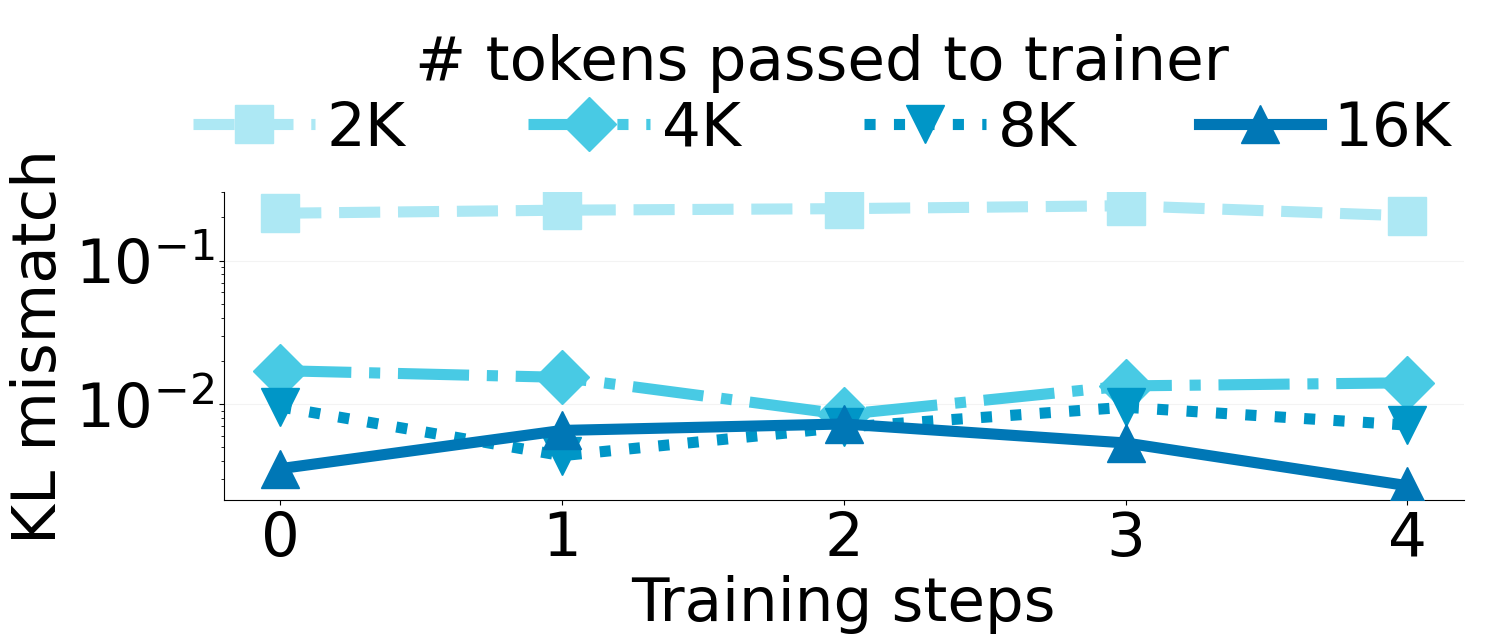

In [24]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# https://coolors.co/palette/ffbe0b-fb5607-ff006e-8338ec-3a86ff
PALETTE = ["#FFBE0B", "#FB5607", "#FF006E", "#8338EC", "#3A86FF"]

OUR_COLOR = "#0077B6"
FULL_ATTN_COLOR = "#E90909"
PALETTE = ["#3A86FF", "#CAF0F8", "#90DBF4", OUR_COLOR, FULL_ATTN_COLOR]
PALETTE = ["#48CAE4", "#ADE8F4", "#3A86FF", OUR_COLOR, FULL_ATTN_COLOR]
PALETTE = ["#48CAE4", "#ADE8F4", "#3A86FF", "#0077B6", "#E90909"]
PALETTE = [OUR_COLOR, OUR_COLOR, OUR_COLOR, OUR_COLOR, FULL_ATTN_COLOR]
PALETTE = ["#ADE8F4", "#48CAE4", "#0096C7", OUR_COLOR, FULL_ATTN_COLOR]
MARKERS = ["s", "D", "v", "^", "o"]
LINESTYLES = ["--", "-.", ":", "-", "-"]     # Full stays solid too, but red separates it

FONTSIZE = 44
LINEWIDTH = 8
MARKERSIZE = 28

csv = r"""
"Step","swmix2kpass16knonup-trainer - mismatch_kl/mean","swmix2kpass16knonup-trainer - mismatch_kl/mean__MIN","swmix2kpass16knonup-trainer - mismatch_kl/mean__MAX","swpure2kpass16knonup-trainer - mismatch_kl/mean","swpure2kpass16knonup-trainer - mismatch_kl/mean__MIN","swpure2kpass16knonup-trainer - mismatch_kl/mean__MAX","swf2kpass16knonup-trainer - mismatch_kl/mean","swf2kpass16knonup-trainer - mismatch_kl/mean__MIN","swf2kpass16knonup-trainer - mismatch_kl/mean__MAX","fullattnpassbaseline2kflex-trainer - mismatch_kl/mean","fullattnpassbaseline2kflex-trainer - mismatch_kl/mean__MIN","fullattnpassbaseline2kflex-trainer - mismatch_kl/mean__MAX","swf2kpass16k-trainer - mismatch_kl/mean","swf2kpass16k-trainer - mismatch_kl/mean__MIN","swf2kpass16k-trainer - mismatch_kl/mean__MAX","swf2kpass8k-trainer - mismatch_kl/mean","swf2kpass8k-trainer - mismatch_kl/mean__MIN","swf2kpass8k-trainer - mismatch_kl/mean__MAX","swf2kpass4k-trainer - mismatch_kl/mean","swf2kpass4k-trainer - mismatch_kl/mean__MIN","swf2kpass4k-trainer - mismatch_kl/mean__MAX","swf2kpass2k-trainer - mismatch_kl/mean","swf2kpass2k-trainer - mismatch_kl/mean__MIN","swf2kpass2k-trainer - mismatch_kl/mean__MAX","fullattnpassbaseline2k-trainer - mismatch_kl/mean","fullattnpassbaseline2k-trainer - mismatch_kl/mean__MIN","fullattnpassbaseline2k-trainer - mismatch_kl/mean__MAX"
"0","1.5484280586242676","1.5484280586242676","1.5484280586242676","0.0004258897388353944","0.0004258897388353944","0.0004258897388353944","0.0025667359586805105","0.0025667359586805105","0.0025667359586805105","0.0009335725917480886","0.0009335725917480886","0.0009335725917480886","0.0035585593432188034","0.0035585593432188034","0.0035585593432188034","0.009572703391313553","0.009572703391313553","0.009572703391313553","0.017113767564296722","0.017113767564296722","0.017113767564296722","0.21336209774017334","0.21336209774017334","0.21336209774017334","0.0010547228157520294","0.0010547228157520294","0.0010547228157520294"
"1","0.7633897066116333","0.7633897066116333","0.7633897066116333","0.0002948338515125215","0.0002948338515125215","0.0002948338515125215","0.012648886069655418","0.012648886069655418","0.012648886069655418","0.0011232474353164434","0.0011232474353164434","0.0011232474353164434","0.00656675361096859","0.00656675361096859","0.00656675361096859","0.004381649661809206","0.004381649661809206","0.004381649661809206","0.015373315662145615","0.015373315662145615","0.015373315662145615","0.22408053278923035","0.22408053278923035","0.22408053278923035","0.0011395243927836418","0.0011395243927836418","0.0011395243927836418"
"2","1.522037148475647","1.522037148475647","1.522037148475647","0.0005174019606783986","0.0005174019606783986","0.0005174019606783986","0.0056639667600393295","0.0056639667600393295","0.0056639667600393295","0.0011109786573797464","0.0011109786573797464","0.0011109786573797464","0.0072841951623559","0.0072841951623559","0.0072841951623559","0.006914728786796331","0.006914728786796331","0.006914728786796331","0.008485427126288414","0.008485427126288414","0.008485427126288414","0.22962850332260132","0.22962850332260132","0.22962850332260132","0.0010735876858234406","0.0010735876858234406","0.0010735876858234406"
"3","1.3681598901748657","1.3681598901748657","1.3681598901748657","0.0006892636301927269","0.0006892636301927269","0.0006892636301927269","0.007086349651217461","0.007086349651217461","0.007086349651217461","0.0010234396904706955","0.0010234396904706955","0.0010234396904706955","0.005372162908315659","0.005372162908315659","0.005372162908315659","0.009521824307739735","0.009521824307739735","0.009521824307739735","0.013401132076978683","0.013401132076978683","0.013401132076978683","0.2406451255083084","0.2406451255083084","0.2406451255083084","0.0010575673077255487","0.0010575673077255487","0.0010575673077255487"
"4","1.6022939682006836","1.6022939682006836","1.6022939682006836","0.0003514703130349517","0.0003514703130349517","0.0003514703130349517","0.00813819095492363","0.00813819095492363","0.00813819095492363","0.000982214231044054","0.000982214231044054","0.000982214231044054","0.00270745437592268","0.00270745437592268","0.00270745437592268","0.007153935730457306","0.007153935730457306","0.007153935730457306","0.014090471900999546","0.014090471900999546","0.014090471900999546","0.2045307159423828","0.2045307159423828","0.2045307159423828","0.001089481171220541","0.001089481171220541","0.001089481171220541"
"5","1.3667552471160889","1.3667552471160889","1.3667552471160889","0.0007551410235464573","0.0007551410235464573","0.0007551410235464573","0.00824857410043478","0.00824857410043478","0.00824857410043478","0.001064142445102334","0.001064142445102334","0.001064142445102334","0.00563308410346508","0.00563308410346508","0.00563308410346508","0.011755898594856262","0.011755898594856262","0.011755898594856262","0.009803143329918385","0.009803143329918385","0.009803143329918385","0.20415762066841125","0.20415762066841125","0.20415762066841125","0.0011014380725100636","0.0011014380725100636","0.0011014380725100636"
"6","1.6450417041778564","1.6450417041778564","1.6450417041778564","0.0006303537520579994","0.0006303537520579994","0.0006303537520579994","0.007806688547134399","0.007806688547134399","0.007806688547134399","0.0010042907670140266","0.0010042907670140266","0.0010042907670140266","0.007514073513448238","0.007514073513448238","0.007514073513448238","0.00621403381228447","0.00621403381228447","0.00621403381228447","0.011423194780945778","0.011423194780945778","0.011423194780945778","0.27415353059768677","0.27415353059768677","0.27415353059768677","0.001110341283492744","0.001110341283492744","0.001110341283492744"
"7","1.4991157054901123","1.4991157054901123","1.4991157054901123","0.0006889151409268379","0.0006889151409268379","0.0006889151409268379","0.003834773087874055","0.003834773087874055","0.003834773087874055","0.0009965492645278573","0.0009965492645278573","0.0009965492645278573","0.006783327553421259","0.006783327553421259","0.006783327553421259","0.0065815565176308155","0.0065815565176308155","0.0065815565176308155","0.011758280918002129","0.011758280918002129","0.011758280918002129","0.2135586142539978","0.2135586142539978","0.2135586142539978","0.00105323176831007","0.00105323176831007","0.00105323176831007"
"""

# -----------------------------
# Load + filter data
# -----------------------------
df = pd.read_csv(io.StringIO(csv.strip()))
df["Step"] = df["Step"].astype(int)

# only first 5 steps
df = df[df["Step"] < 5].copy()
steps = df["Step"].to_numpy()

# -----------------------------
# Columns to plot (1 line each)
# Order matches legend semantics
# -----------------------------
COLS = [
    ("swf2kpass2k-trainer - mismatch_kl/mean", "2K"),
    ("swf2kpass4k-trainer - mismatch_kl/mean", "4K"),
    ("swf2kpass8k-trainer - mismatch_kl/mean", "8K"),
    ("swf2kpass16k-trainer - mismatch_kl/mean", "16K"),
    #("fullattnpassbaseline2k-trainer - mismatch_kl/mean", "Full"), # different than 16K likely due to kernel differences
]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(16, 4))

for i, (col, label) in enumerate(COLS):
    y = df[col].astype(float).to_numpy()

    ax.plot(
        steps,
        y,
        label=label,
        color=PALETTE[i],
        linewidth=LINEWIDTH,
        marker=MARKERS[i],
        ms=MARKERSIZE,
        linestyle=LINESTYLES[i],
        zorder=3,
        # markerfacecolor="white",
        # markeredgecolor=PALETTE[i],
        # markeredgewidth=3.5,
    )

# -----------------------------
# Axes / styling
# -----------------------------
ax.set_yscale("log")

ax.set_xticks(steps)
ax.set_xticklabels(steps, fontsize=FONTSIZE)
ax.tick_params(axis="y", labelsize=FONTSIZE)

ax.set_xlabel("Training steps", fontsize=FONTSIZE)
ax.set_ylabel("KL mismatch", fontsize=FONTSIZE)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    fontsize=FONTSIZE,
    frameon=False,
    title="# tokens passed to trainer",
    loc=(-0.045, 1.03),
#    title_fontproperties={"weight": "bold", "size": FONTSIZE},
    title_fontproperties={"size": FONTSIZE},
    ncol=5,
    labelspacing=0.1,
    handletextpad=0.2,
#    columnspacing=0.2,
)

ax.yaxis.grid(True, which="major", alpha=0.15)

#plt.tight_layout()
#plt.subplots_adjust(top=1)
plt.savefig("kl_vs_steps.png", bbox_inches="tight")
plt.savefig("kl_vs_steps.pdf", bbox_inches="tight")
plt.show()


##### Plot: Continue vs Reset PE

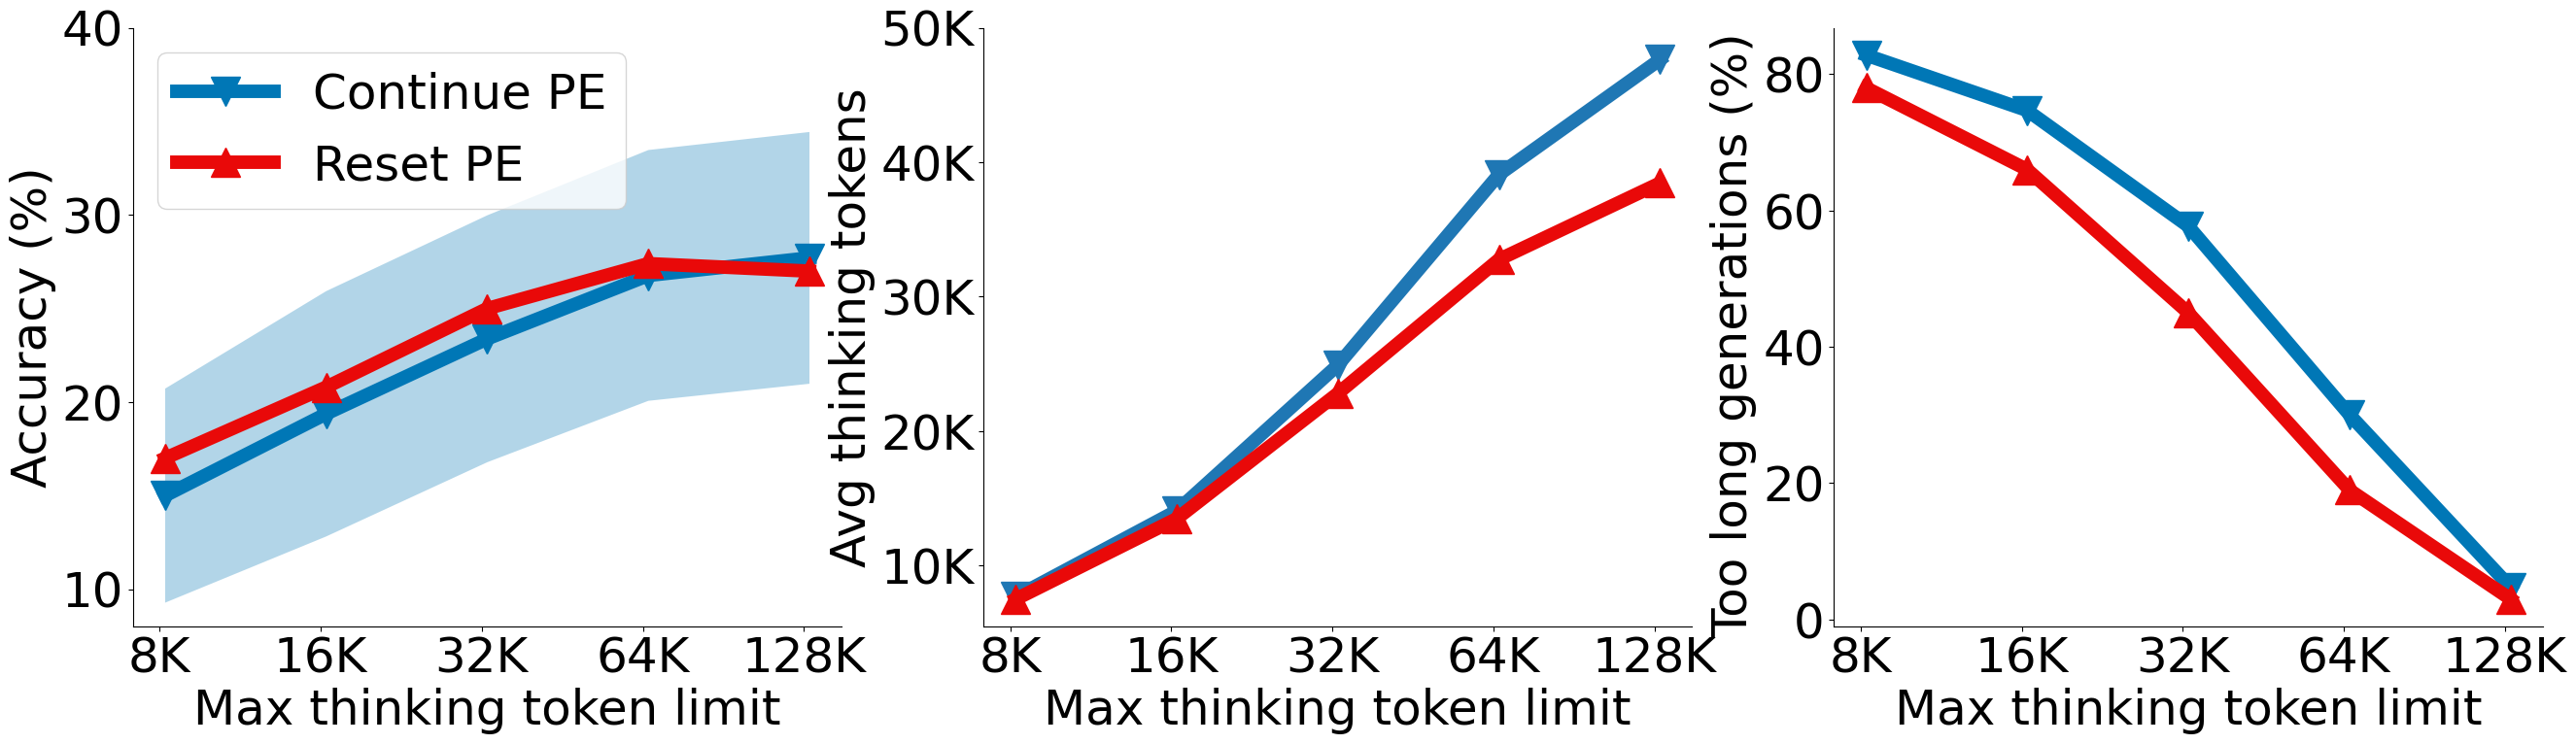

In [25]:
MAX_LENS = [8192, 16384, 32768, 65536, 131072]

# unfort lost the result files but saved the scores
scores = [17.0, 20.8, 25.0, 27.4, 27.0]
avg_toks = [7481, 13473, 22796, 32762, 38452]
too_long = [0.78, 0.66, 0.45, 0.19, 0.03]

import matplotlib.pyplot as plt
import numpy as np

FONTSIZE = 36
LINEWIDTH = 10
MARKERSIZE = 22
DASHES=(2, 1)

# Create the plot
fig, axes = plt.subplots(figsize=(32, 8), ncols=3)


x_str = ["8K", "16K", "32K", "64K", "128K"]
x_val = [np.log2(8000), np.log2(16000), np.log2(32000), np.log2(64000), np.log2(128000)]

### AIME24 PERF ###
ax = axes[0]

# Data points
y_vals = [qwen_swf2048['results']['aime25_nofigures_tok524288_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS]
x_vals_log = [np.log2(x) for x in MAX_LENS]
y_vals_scaled = [y * 100 for y in y_vals]
ax.plot(
    x_vals_log,
    y_vals_scaled,
    label="Continue PE",
    color=OUR_COLOR,
    linewidth=LINEWIDTH,
    ms=MARKERSIZE,
    marker='v',
)#, s=MARKERSIZE*15, zorder=2, marker='o')

ax.plot(
    x_vals_log,
    scores,
    label="Reset PE",
    color=FULL_ATTN_COLOR,
    linewidth=LINEWIDTH,
    ms=MARKERSIZE,
    marker='^',
)

scores_std = [qwen_swf2048['results']['aime25_nofigures_tok524288_agg64'][f'avg@{l}@64_stderr,all']*100 for l in MAX_LENS]

ax.fill_between(
    x_vals_log,
    np.array(y_vals_scaled) - np.array(scores_std),
    np.array(y_vals_scaled) + np.array(scores_std),
    alpha=0.3,
    facecolor=OUR_COLOR,
)

ax.legend(
    fontsize=FONTSIZE,
#    frameon=False
)


ax.set_xticks(x_val, x_str, fontsize=FONTSIZE)
# a, b = ax.get_xlim()
ax.set_yticks(ax.get_yticks()[1::2], [int(x) for x in ax.get_yticks()[1::2]], fontsize=FONTSIZE)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel("Max thinking token limit", fontsize=FONTSIZE)
ax.set_ylabel("Accuracy (%)", fontsize=FONTSIZE)

### Avg length ###
ax = axes[1]

y_vals = [qwen_swf2048['results']['aime25_nofigures_tok524288_agg64'][f'tok@{l}@64,all'] for l in MAX_LENS]
x_vals_log = [np.log2(x) for x in MAX_LENS]
ax.plot(
    x_vals_log,
    y_vals,
    label="Continue PE",
    linewidth=LINEWIDTH,
    ms=MARKERSIZE,
    marker='v',
)

scores_std = [qwen_swf2048['results']['aime25_nofigures_tok524288_agg64'][f'tok@{l}@64_stderr,all']*100 for l in MAX_LENS]

ax.plot(
    x_vals_log,
    avg_toks,
    label="Reset PE",
    color=FULL_ATTN_COLOR,
    linewidth=LINEWIDTH,
    ms=MARKERSIZE,
    marker='^',
)#, s=

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel("Max thinking token limit", fontsize=FONTSIZE)
ax.set_ylabel("Avg thinking tokens", fontsize=FONTSIZE)
ax.set_xticks(x_val, x_str, fontsize=FONTSIZE)
y_val = [10000, 20000, 30000, 40000, 50000]
y_str = ["10K", "20K", "30K", "40K", "50K"]
ax.set_yticks(y_val, y_str, fontsize=FONTSIZE)

### Too Long ###
ax = axes[2]

y_vals = [qwen_swf2048['results']['aime25_nofigures_tok524288_agg64'][f'too_long@{l}@64,all'] for l in MAX_LENS]

x_vals_log = [np.log2(x) for x in MAX_LENS]
y_vals_scaled = [y * 100 for y in y_vals]
ax.plot(
    x_vals_log,
    y_vals_scaled,
    label="Continue PE",
    color=OUR_COLOR,
    linewidth=LINEWIDTH,
    ms=MARKERSIZE,
    marker='v',
)

y_vals_scaled = [y * 100 for y in too_long]
ax.plot(
    x_vals_log,
    y_vals_scaled,
    label="Reset PE",
    color=FULL_ATTN_COLOR,
    linewidth=LINEWIDTH,
    ms=MARKERSIZE,
    marker='^',
)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel("Max thinking token limit", fontsize=FONTSIZE)
ax.set_ylabel("Too long generations (%) ", fontsize=FONTSIZE)
ax.set_xticks(x_val, x_str, fontsize=FONTSIZE)
ax.set_yticks(ax.get_yticks()[1::2], [int(x) for x in ax.get_yticks()[1::2]], fontsize=FONTSIZE)


plt.savefig("pe.png", bbox_inches='tight')
plt.savefig("pe.pdf", bbox_inches='tight')
plt.show()


##### Plot: tok/s

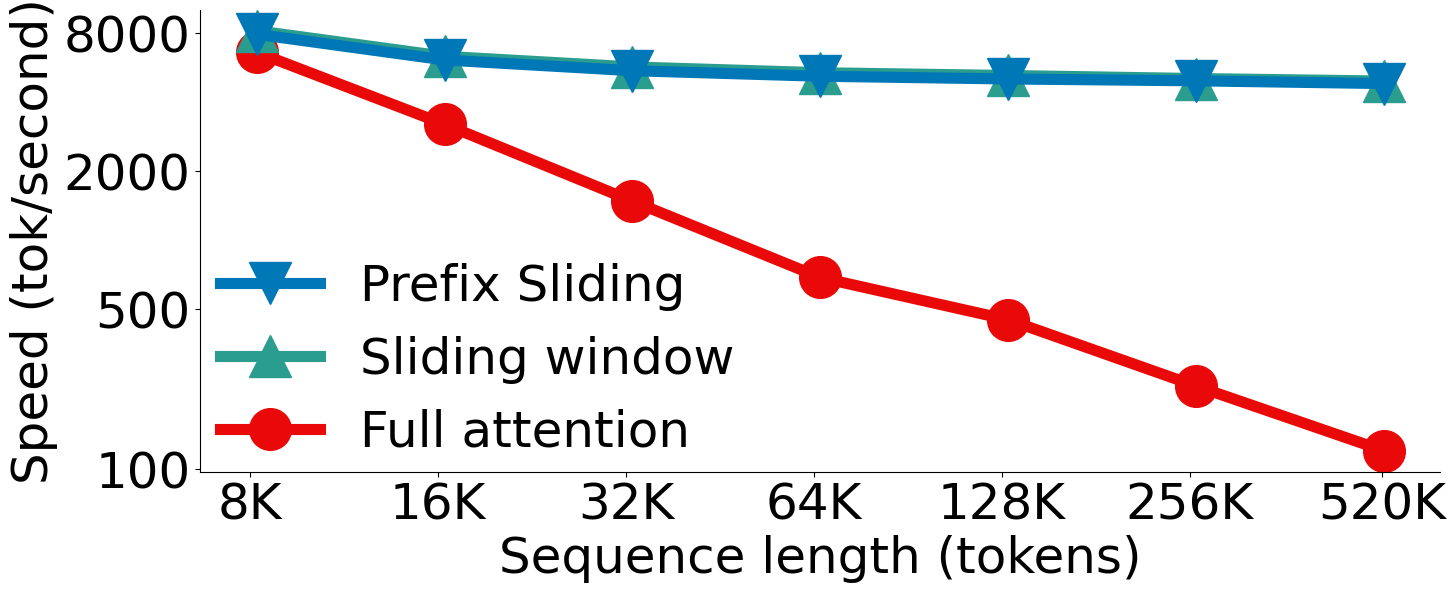

In [26]:
# https://coolors.co/palette/ffbe0b-fb5607-ff006e-8338ec-3a86ff
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE = 36
LINEWIDTH = 8
MARKERSIZE = 30
DASHES=(2, 1)
MAX_LENS = [
    8192,
    16384,
    32768,
    65536,
    131072,
    262144,
    524288,
]

# Create the plot
fig, axes = plt.subplots(figsize=(16, 6), ncols=1)

ax = axes

y_vals = [results['results']['Qwen/Qwen3-1.7B'][str(l)]['SW']['4096'] for l in MAX_LENS]
x_vals_log = [np.log2(x) for x in MAX_LENS]
y_vals_scaled = [y for y in y_vals]
y_vals_scaled = [np.log2(y) for y in y_vals]
ax.plot(
    x_vals_log,
    y_vals_scaled,
    label="Prefix Sliding",
    color=OUR_COLOR,
    zorder=3,
    linewidth=LINEWIDTH,
    ms=MARKERSIZE,
    marker='v',
)

y_vals = [results['results']['Qwen/Qwen3-1.7B'][str(l)]['SWR']['4096'] for l in MAX_LENS]
x_vals_log = [np.log2(x) for x in MAX_LENS]
y_vals_scaled = [y for y in y_vals]
y_vals_scaled = [np.log2(y) for y in y_vals]
ax.plot(
    x_vals_log,
    y_vals_scaled,
    label="Sliding window",
    color="#2A9D8F",
    zorder=2,
    linewidth=LINEWIDTH,
    ms=MARKERSIZE,
    marker='^',
)

y_vals = [results['results']['Qwen/Qwen3-1.7B'][str(l)]['Full'] for l in MAX_LENS]
x_vals_log = [np.log2(x) for x in MAX_LENS]
y_vals_scaled = [y for y in y_vals]
y_vals_scaled = [np.log2(y) for y in y_vals]
ax.plot(
    x_vals_log,
    y_vals_scaled,
    label="Full attention",
    color=FULL_ATTN_COLOR,
    zorder=1,
    linewidth=LINEWIDTH,
    ms=MARKERSIZE,
    marker='o',
)

x_ticks = [
    8000,
    16000,
    32000,
    64000,
    128000,
    256000,
    520000,
]
x_log = [np.log2(x) for x in x_ticks]
x_ticks = [
    "8K",
    "16K",
    "32K",
    "64K",
    "128K",
    "256K",
    "520K",
]
ax.set_xticks(x_log, x_ticks, fontsize=FONTSIZE)

y_ticks = [
    100,
    #250,
    500,
    #1000,
    2000,
    #4000,
    8000,
]
y_log = [np.log2(x) for x in y_ticks]

ax.set_yticks(y_log, [int(x) for x in y_ticks], fontsize=FONTSIZE)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel("Sequence length (tokens)", fontsize=FONTSIZE)
ax.set_ylabel("Speed (tok/second)", fontsize=FONTSIZE)

plt.legend(
    fontsize=FONTSIZE,
    frameon=False,
    loc=(0,-0.01),
)

plt.savefig("toks.png", bbox_inches='tight')
plt.savefig("toks.pdf", bbox_inches='tight')
plt.show()

##### Plot: RL 7B + Downstream

In [27]:
from google.colab import userdata
import wandb
wandb.login(key=userdata.get('WANDB_MAIN'))
api = wandb.Api()

/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: muennighoff (anysphere-wandb) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [28]:
!rm -r *.pkl

rm: cannot remove '*.pkl': No such file or directory


In [29]:
import wandb
api = wandb.Api()
run = api.run(f"muennighoff/primerl/ghyxg69g")

In [30]:
keys = ["reward/mean"]
end_step = 9999
run.history(samples=100, keys=keys, x_axis="step", pandas=False, stream="default")

[{'step': 0, 'reward/mean': 0.8779296875},
 {'step': 3, 'reward/mean': 0.7431640625},
 {'step': 4, 'reward/mean': 0.8212890625},
 {'step': 5, 'reward/mean': 0.779296875},
 {'step': 6, 'reward/mean': 0.802734375},
 {'step': 7, 'reward/mean': 0.796875},
 {'step': 8, 'reward/mean': 0.8525390625},
 {'step': 9, 'reward/mean': 0.7705078125},
 {'step': 10, 'reward/mean': 0.7548828125},
 {'step': 12, 'reward/mean': 0.794921875},
 {'step': 13, 'reward/mean': 0.73828125},
 {'step': 14, 'reward/mean': 0.7802734375},
 {'step': 17, 'reward/mean': 0.8125},
 {'step': 18, 'reward/mean': 0.7470703125},
 {'step': 19, 'reward/mean': 0.837890625},
 {'step': 20, 'reward/mean': 0.84375},
 {'step': 21, 'reward/mean': 0.7802734375},
 {'step': 22, 'reward/mean': 0.7734375},
 {'step': 23, 'reward/mean': 0.7734375},
 {'step': 24, 'reward/mean': 0.802734375},
 {'step': 25, 'reward/mean': 0.7734375},
 {'step': 26, 'reward/mean': 0.8056640625},
 {'step': 27, 'reward/mean': 0.802734375},
 {'step': 29, 'reward/mean':

In [31]:
# Not doing in W&B as
# 1) doesnt fit template/style of other plots
# 2) cannot change order of lines i.e. which one is on top

import os
import pickle

def avg_mmlu(x, keys):
    if len(keys) == 1: return x[keys[0]]
    if "var" in keys[0]:
        return 0.215*x['eval/downstream/mmlu_stem_var_len_norm'] + 0.335*x['eval/downstream/mmlu_humanities_var_len_norm'] + 0.219*x['eval/downstream/mmlu_social_sciences_var_len_norm'] + 0.231*x['eval/downstream/mmlu_other_var_len_norm']
    return 0.215*x['eval/downstream/mmlu_stem_mc_5shot_len_norm'] + 0.335*x['eval/downstream/mmlu_humanities_mc_5shot_len_norm'] + 0.219*x['eval/downstream/mmlu_social_sciences_mc_5shot_len_norm'] + 0.231*x['eval/downstream/mmlu_other_mc_5shot_len_norm']

def get_data(data_dict, suffix, runs=None, sample_every_n=1, wandb="muennighoff/primerl/", check_steps=False):
    # Load files if exist
    if os.path.exists("train" + suffix + ".pkl"):
      for k, v in data_dict.items():
        with open(k + suffix + ".pkl", "rb") as f:
          data_dict[k][1] = pickle.load(f)

    else:
      import wandb
      api = wandb.Api()

      for run_id, end_step in runs:
          print("Run ID:", run_id)
          samples = 999_999 // sample_every_n
          run = api.run(f"muennighoff/primerl/{run_id}")
          for name, (keys, data) in data_dict.items():
              if check_steps:
                  data += [
                      (x['step'], avg_mmlu(x, keys)) for x in run.history(samples=samples, keys=keys, x_axis="step", pandas=False, stream="default") if x['step'] <= end_step
                  ]
              else:
                  data += [
                      (x['step'], avg_mmlu(x, keys)) for x in run.history(samples=samples, keys=keys, x_axis="step", pandas=False, stream="default")
                  ]
      # Save to file
      for k, v in data_dict.items():
        with open(k + suffix + ".pkl", "wb") as f:
          pickle.dump(v[1], f)

us_runs = [
    ("ghyxg69g", 125),
]

full_runs = [
    ("8xmkcpyo", 125),
]


DATA_US = {
    "train": [["reward/mean"], []],
    "aime24": [["eval/aime2024/avg@32"], []],
}

DATA_FULL = {
    "train": [["reward/mean"], []],
    "aime24": [["eval/aime2024/avg@32"], []],
}

get_data(DATA_US, "_us", us_runs, check_steps=True)
get_data(DATA_FULL, "_full", full_runs, check_steps=True)

print(len(DATA_US["train"][1]))

Run ID: ghyxg69g
Run ID: 8xmkcpyo
126


In [32]:
from typing import List
import os

# https://stackoverflow.com/questions/42281844/what-is-the-mathematics-behind-the-smoothing-parameter-in-tensorboards-scalar
def smooth(scalars: List[float], weight: float) -> List[float]:  # Weight between 0 and 1
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor the last smoothed value

    return smoothed

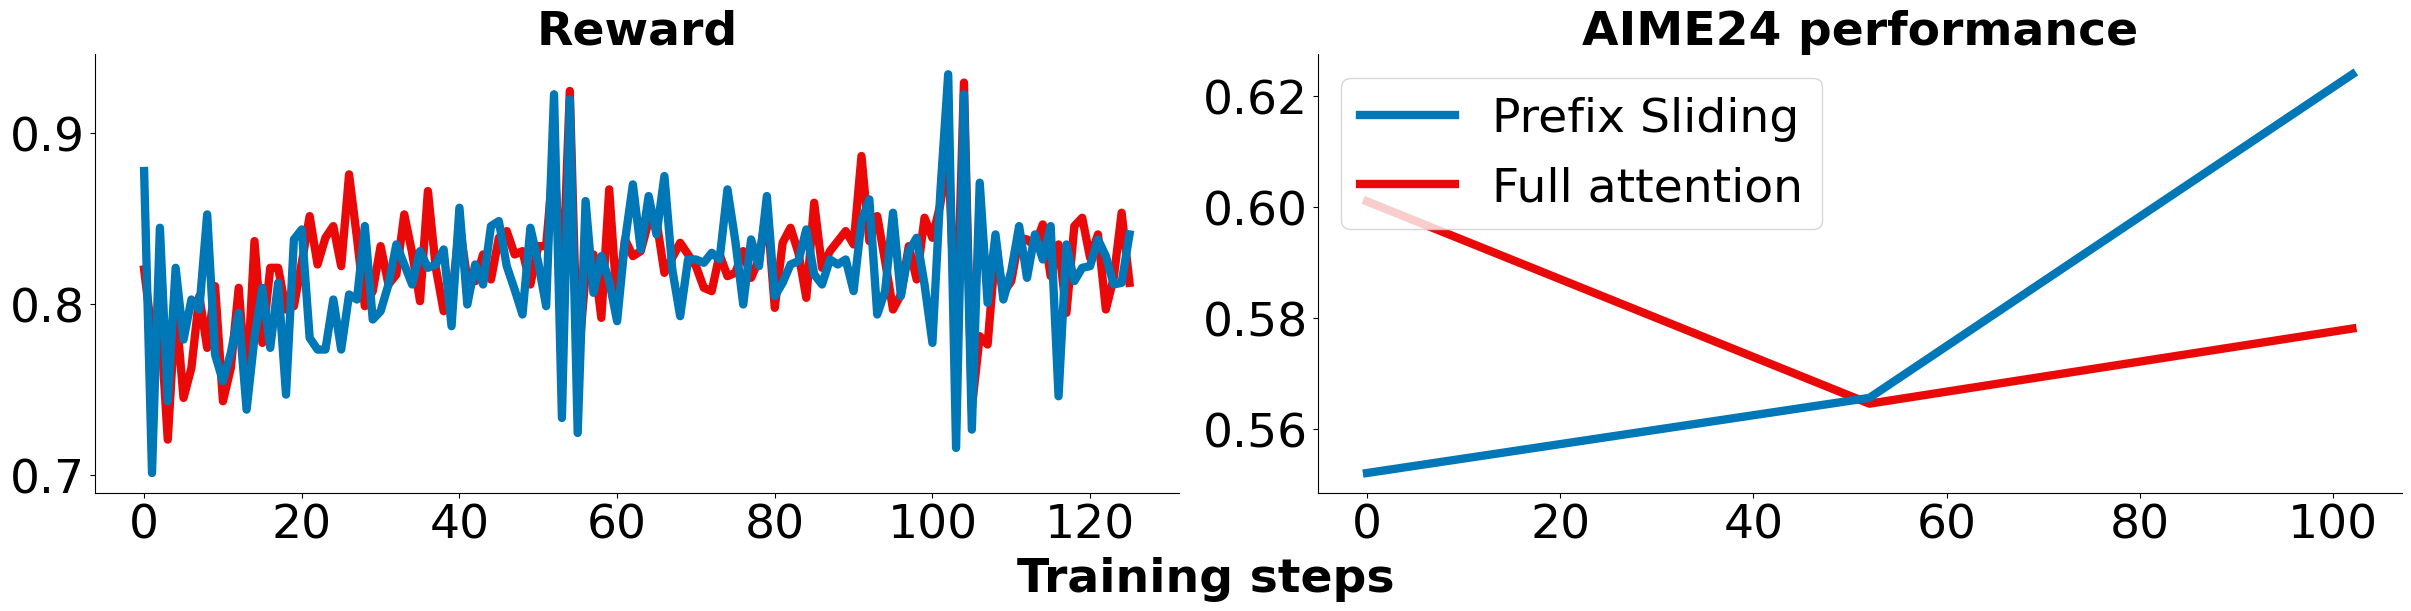

In [33]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE = 34
TOKENS_PER_STEP = 4096 * 1024

fig, axes = plt.subplots(figsize=(24, 6), ncols=2, sharex=False, layout='constrained')

titles = [
    "Reward",
    "AIME24 performance",
]

colors = [
    "#F0539B",
    "#43C5E0",
    "#2E3168",
    "#FDBE15",
]

data = [
  (DATA_US["train"], DATA_FULL["train"]),
  (DATA_US["aime24"], DATA_FULL["aime24"]),
]

for i, ax in enumerate(axes.flatten()):
    mult = 1 # 100 if i >=3 else 1
    ax.plot(
        [x[0] for x in data[i][1][1]],
        # smooth(
        [x[1]*mult for x in data[i][1][1]],
        #, weight=0.95),
        linewidth=6.0,
        color=FULL_ATTN_COLOR,
        label="Full attention",
    )
    ax.plot(
        [x[0] for x in data[i][0][1]],
        # smooth(
        [x[1]*mult for x in data[i][0][1]],
        # weight=0.95),
        linewidth=6.0,
        color=OUR_COLOR,
        label="Prefix Sliding",
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(axis='both', which='major', labelsize=FONTSIZE)

    ax.set_title(titles[i], fontsize=FONTSIZE, fontweight='bold')

    # if i < 3:
    #   ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    # elif i >= 3:
    #   ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.0f'))

    # x_ticks = [10, 40, 70, 100, 130]
    # # Transform billion tokens to steps
    # x_ticks_loc = [x * 1e9 / TOKENS_PER_STEP for x in x_ticks]
    # ax.set_xticks(x_ticks_loc, x_ticks)

    # if i == 0:
    #     a, b = ax.get_ylim()
    #     ax.set_ylim([2.2, 4.2])

    if i == 0:
      y_ticks_str = ["0.2", "0.3", "0.4", "0.5"]
      y_ticks_float = [0.2, 0.3, 0.4, 0.5]

      # ax.set_yticks(y_ticks_float, y_ticks_str, fontsize=FONTSIZE)
    #else:
      # legend
    if i == 1:
      handles, labels = ax.get_legend_handles_labels()
      order = [1, 0]
      ax.legend(
          [handles[idx] for idx in order],
          [labels[idx] for idx in order],
          fontsize=FONTSIZE,
          #frameon=False,
          loc="upper left",
      )

# plt.legend(
#     fontsize=FONTSIZE,
#     frameon=False
# )

# fig.supylabel('Performance', fontsize=FONTSIZE, fontweight='bold')
fig.supxlabel('Training steps', fontsize=FONTSIZE, fontweight='bold')

plt.savefig('rl.pdf', dpi=300, bbox_inches='tight')
plt.savefig('rl.png', dpi=300, bbox_inches='tight')
plt.show()

##### Plot: Triplets

[0.060527146464646464, 0.1900252525252525, 0.335385101010101, 0.36237373737373735, 0.3647411616161616, 0.3652935606060606, 0.36987058080808083]
[0.06376262626262626, 0.1665877525252525, 0.34035669191919193, 0.374447601010101, 0.3757102272727273]
PS - Math
[0.27235684883436423, 0.5580273701918971, 0.8771111918329703, 1.123672706771738, 1.2944669554952137, 1.4013456771242223]
[0.53821875, 0.801125, 0.88128125, 0.90834375, 0.9148125, 0.915375]
Full - Math
[0.2722198218764328, 0.6831454389903585, 1.7190575947164413, 4.02961015898729, 8.83971284544499]
[0.53975, 0.776, 0.8885, 0.9165, 0.91675]


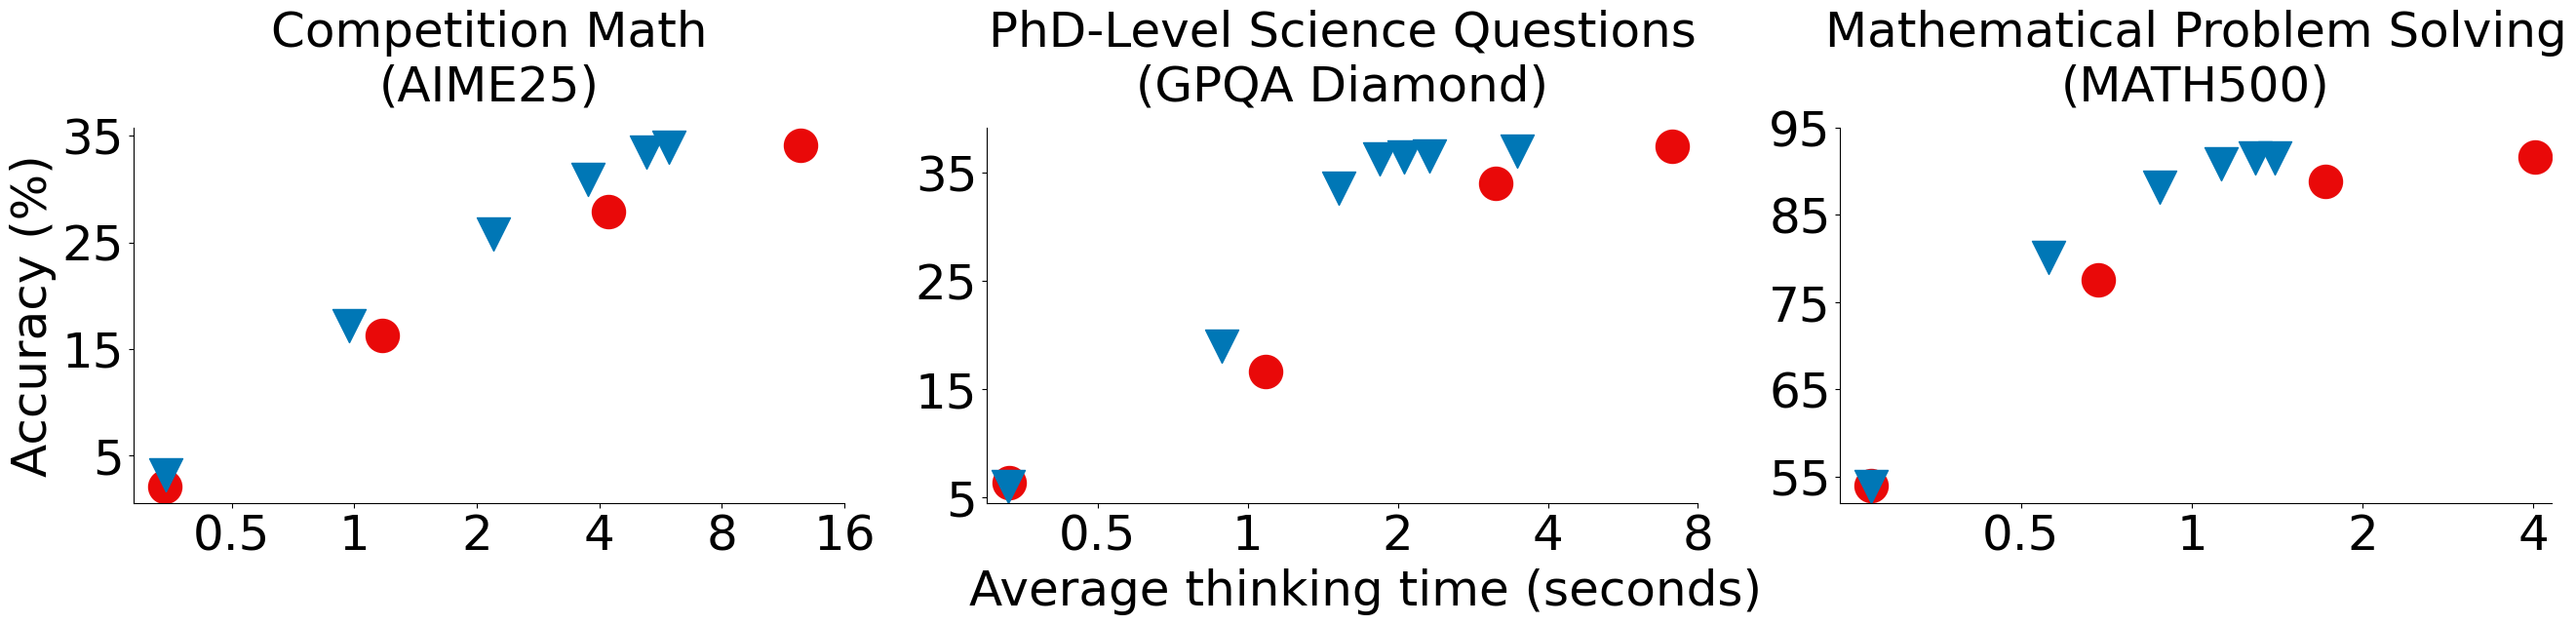

In [34]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE = 36
LINEWIDTH = 7
MARKERSIZE = 40
DASHES=(2, 1)
MAX_LENS = [
#    2048,
    4096,
    8192,
    16384,
    32768,
    65536,
    131072,
    262144,
    524288,
]

# Create the plot
fig, axes = plt.subplots(figsize=(32, 5), ncols=3)

### AIME24 ###
ax = axes[0]

# Data points
x_vals = [(qwen_swf4096['results']['aime25_nofigures_tok524288_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['SW']['4096']) for l in MAX_LENS]
y_vals = [qwen_swf4096['results']['aime25_nofigures_tok524288_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="MethodName", color=OUR_COLOR, s=MARKERSIZE*15, zorder=2, marker='v')

x_vals = [(qwen_full['results']['aime25_nofigures_tok131072_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['Full']) for l in MAX_LENS[:-2]]
y_vals = [qwen_full['results']['aime25_nofigures_tok131072_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS[:-2]]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Full", color=FULL_ATTN_COLOR, s=MARKERSIZE*15, zorder=1)

x_ticks = [0.5, 1, 2, 4, 8, 16]
x_log = [np.log2(x) for x in x_ticks]
#x_log = x_ticks
ax.set_xticks(x_log, x_ticks, fontsize=FONTSIZE)


a, b = ax.get_xlim()
ax.set_yticks(ax.get_yticks()[1::2], [int(x) for x in ax.get_yticks()[1::2]], fontsize=FONTSIZE)
# ax.set_yticks(ax.get_yticks()[1::2], [int(x) for x in ax.get_yticks()[1::2]], fontsize=FONTSIZE)
# ax.set_xlim(np.log2(400), np.log2(8000))

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylabel("Accuracy (%)", fontsize=FONTSIZE)
ax.set_title("Competition Math\n(AIME25)", fontsize=FONTSIZE, pad=20)


### GPQA ###
ax = axes[1]

x_vals = [(qwen_swf4096_gpqa['results']['gpqa_diamond_openai_tok524288_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['SW']['4096']) for l in MAX_LENS]
y_vals = [qwen_swf4096_gpqa['results']['gpqa_diamond_openai_tok524288_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
print(y_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="MethodName", color=OUR_COLOR, s=MARKERSIZE*15, zorder=2, marker='v')

x_vals = [(qwen_full_gpqa['results']['gpqa_diamond_openai_tok131072_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['Full']) for l in MAX_LENS[:-2]]
y_vals = [qwen_full_gpqa['results']['gpqa_diamond_openai_tok131072_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS[:-2]]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
print(y_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Full", color=FULL_ATTN_COLOR, s=MARKERSIZE*15, zorder=1)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("PhD-Level Science Questions\n(GPQA Diamond)", fontsize=FONTSIZE, pad=20)

x_ticks = [0.2, 0.5, 1, 2, 4, 8, 16]
x_log = [np.log2(x) for x in x_ticks]
#x_log = x_ticks
ax.set_xticks(x_log, x_ticks, fontsize=FONTSIZE)
ax.set_yticks(ax.get_yticks()[1::2], [int(x) for x in ax.get_yticks()[1::2]], fontsize=FONTSIZE)
#ax.legend(fontsize=FONTSIZE,)
ax.set_xlim(np.log2(0.3), np.log2(8))

### MATH ###
ax = axes[2]

x_vals = [(qwen_swf4096_math['results']['openai_math_tok524288_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['SW']['4096']) for l in MAX_LENS]
y_vals = [qwen_swf4096_math['results']['openai_math_tok524288_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
print("PS - Math")
print(x_vals)
print(y_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Prefix Sliding", color=OUR_COLOR, s=MARKERSIZE*15, zorder=2, marker='v')

x_vals = [(qwen_full_math['results']['openai_math_tok262144_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['Full']) for l in MAX_LENS[:-1]]
y_vals = [qwen_full_math['results']['openai_math_tok262144_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS[:-1]]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
print("Full - Math")
print(x_vals)
print(y_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Full Attention", color=FULL_ATTN_COLOR, s=MARKERSIZE*15, zorder=1)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title("Mathematical Problem Solving\n(MATH500)", fontsize=FONTSIZE, pad=20)

x_ticks = [0.5, 1, 2, 4]
x_log = [np.log2(x) for x in x_ticks]
#x_log = x_ticks
ax.set_xticks(x_log, x_ticks, fontsize=FONTSIZE)
ax.set_yticks(ax.get_yticks()[1::2], [int(x) for x in ax.get_yticks()[1::2]], fontsize=FONTSIZE)
ax.set_xlim(np.log2(0.24), np.log2(4.3))

# plt.legend(
#     fontsize=FONTSIZE,
# #    frameon=False
# )

fig.supxlabel("Average thinking time (seconds)", fontsize=FONTSIZE, y=-0.12, x=0.52)
plt.savefig("scaling4096.png", bbox_inches='tight')
plt.savefig("scaling4096.pdf", bbox_inches='tight')
plt.show()

[0.06218434343434343, 0.1613794191919192, 0.35811237373737376, 0.3780776515151515, 0.37855113636363635, 0.37870896464646464, 0.3787878787878788, 0.3802083333333333]


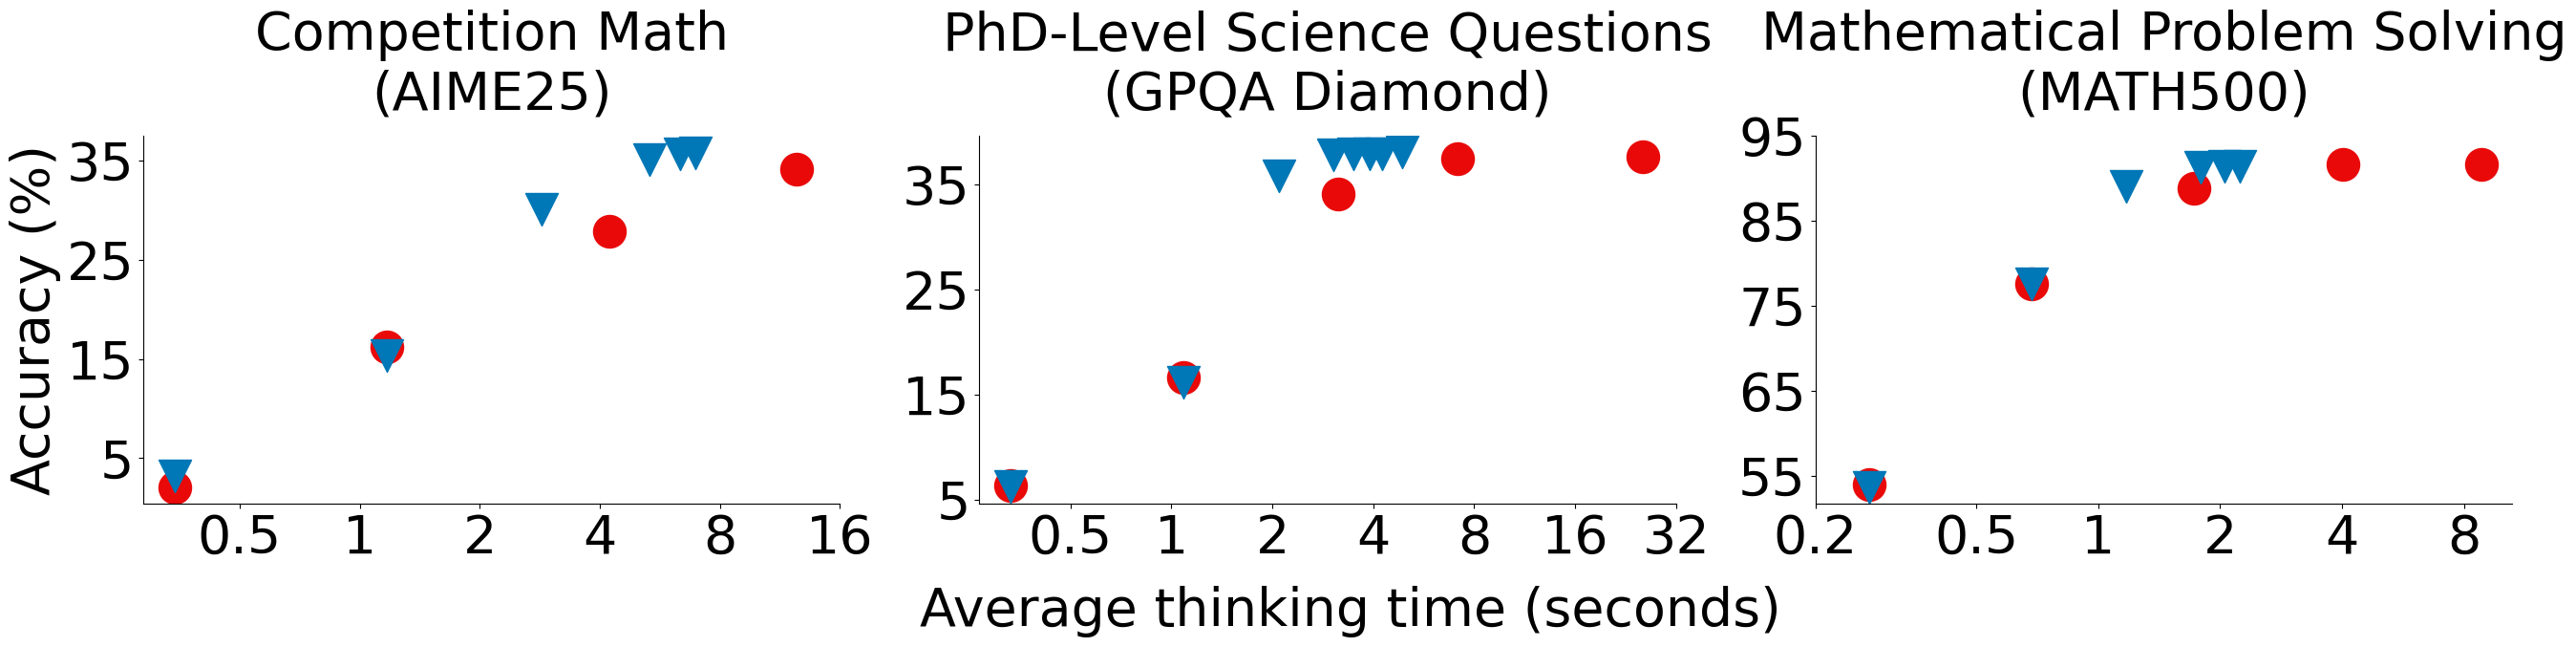

In [35]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE = 40#36
LINEWIDTH = 7
MARKERSIZE = 40
DASHES=(2, 1)
MAX_LENS = [
#    2048,
    4096,
    8192,
    16384,
    32768,
    65536,
    131072,
    262144,
    524288,
]

# Create the plot
fig, axes = plt.subplots(figsize=(32, 5), ncols=3)

### AIME24 ###
ax = axes[0]

# Data points
x_vals = [(qwen_swf8192['results']['aime25_nofigures_tok524288_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['SW']['8192']) for l in MAX_LENS]
y_vals = [qwen_swf8192['results']['aime25_nofigures_tok524288_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Prefix Sliding", color=OUR_COLOR, s=MARKERSIZE*15, zorder=2, marker='v')

x_vals = [(qwen_full['results']['aime25_nofigures_tok131072_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['Full']) for l in MAX_LENS[:-2]]
y_vals = [qwen_full['results']['aime25_nofigures_tok131072_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS[:-2]]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Full", color=FULL_ATTN_COLOR, s=MARKERSIZE*15, zorder=1)

x_ticks = [0.5, 1, 2, 4, 8, 16]
x_log = [np.log2(x) for x in x_ticks]
#x_log = x_ticks
ax.set_xticks(x_log, x_ticks, fontsize=FONTSIZE)

# a, b = ax.get_xlim()
ax.set_yticks(ax.get_yticks()[1::2], [int(x) for x in ax.get_yticks()[1::2]], fontsize=FONTSIZE)
# ax.set_xlim(np.log2(400), np.log2(8000))

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylabel("Accuracy (%)", fontsize=FONTSIZE)
ax.set_title("Competition Math\n(AIME25)", fontsize=FONTSIZE, pad=20)

### GPQA ###
ax = axes[1]

x_vals = [(qwen_swf8192_gpqa['results']['gpqa_diamond_openai_tok524288_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['SW']['8192']) for l in MAX_LENS]
y_vals = [qwen_swf8192_gpqa['results']['gpqa_diamond_openai_tok524288_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
print(y_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Prefix Sliding", color=OUR_COLOR, s=MARKERSIZE*15, zorder=2, marker='v')

x_vals = [(qwen_full_gpqa['results']['gpqa_diamond_openai_tok131072_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['Full']) for l in MAX_LENS[:-2]]
y_vals = [qwen_full_gpqa['results']['gpqa_diamond_openai_tok131072_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS[:-2]]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Full", color=FULL_ATTN_COLOR, s=MARKERSIZE*15, zorder=1)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("PhD-Level Science Questions\n(GPQA Diamond)", fontsize=FONTSIZE, pad=20)

x_ticks = [0.5, 1, 2, 4, 8, 16, 32]
x_log = [np.log2(x) for x in x_ticks]
#x_log = x_ticks
ax.set_xticks(x_log, x_ticks, fontsize=FONTSIZE)
ax.set_yticks(ax.get_yticks()[1::2], [int(x) for x in ax.get_yticks()[1::2]], fontsize=FONTSIZE)

### MATH ###
ax = axes[2]

x_vals = [(qwen_swf8192_math['results']['openai_math_tok524288_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['SW']['8192']) for l in MAX_LENS]
y_vals = [qwen_swf8192_math['results']['openai_math_tok524288_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Prefix Sliding", color=OUR_COLOR, s=MARKERSIZE*15, zorder=2, marker='v')

x_vals = [(qwen_full_math['results']['openai_math_tok262144_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['Full']) for l in MAX_LENS[:-1]]
y_vals = [qwen_full_math['results']['openai_math_tok262144_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS[:-1]]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Full Attention", color=FULL_ATTN_COLOR, s=MARKERSIZE*15, zorder=1)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title("Mathematical Problem Solving\n(MATH500)", fontsize=FONTSIZE, pad=20)

x_ticks = [0.2, 0.5, 1, 2, 4, 8]
x_log = [np.log2(x) for x in x_ticks]
#x_log = x_ticks
ax.set_xticks(x_log, x_ticks, fontsize=FONTSIZE)
ax.set_yticks(ax.get_yticks()[1::2], [int(x) for x in ax.get_yticks()[1::2]], fontsize=FONTSIZE)


# plt.legend(
#     fontsize=FONTSIZE,
# #    frameon=False
# )
#fig.supxlabel("Average thinking time (seconds)", fontsize=FONTSIZE, y=-0.12, x=0.52)
fig.supxlabel("Average thinking time (seconds)", fontsize=FONTSIZE, y=-0.17, x=0.52)

plt.savefig("scaling8192.png", bbox_inches='tight')
plt.savefig("scaling8192.pdf", bbox_inches='tight')
plt.show()

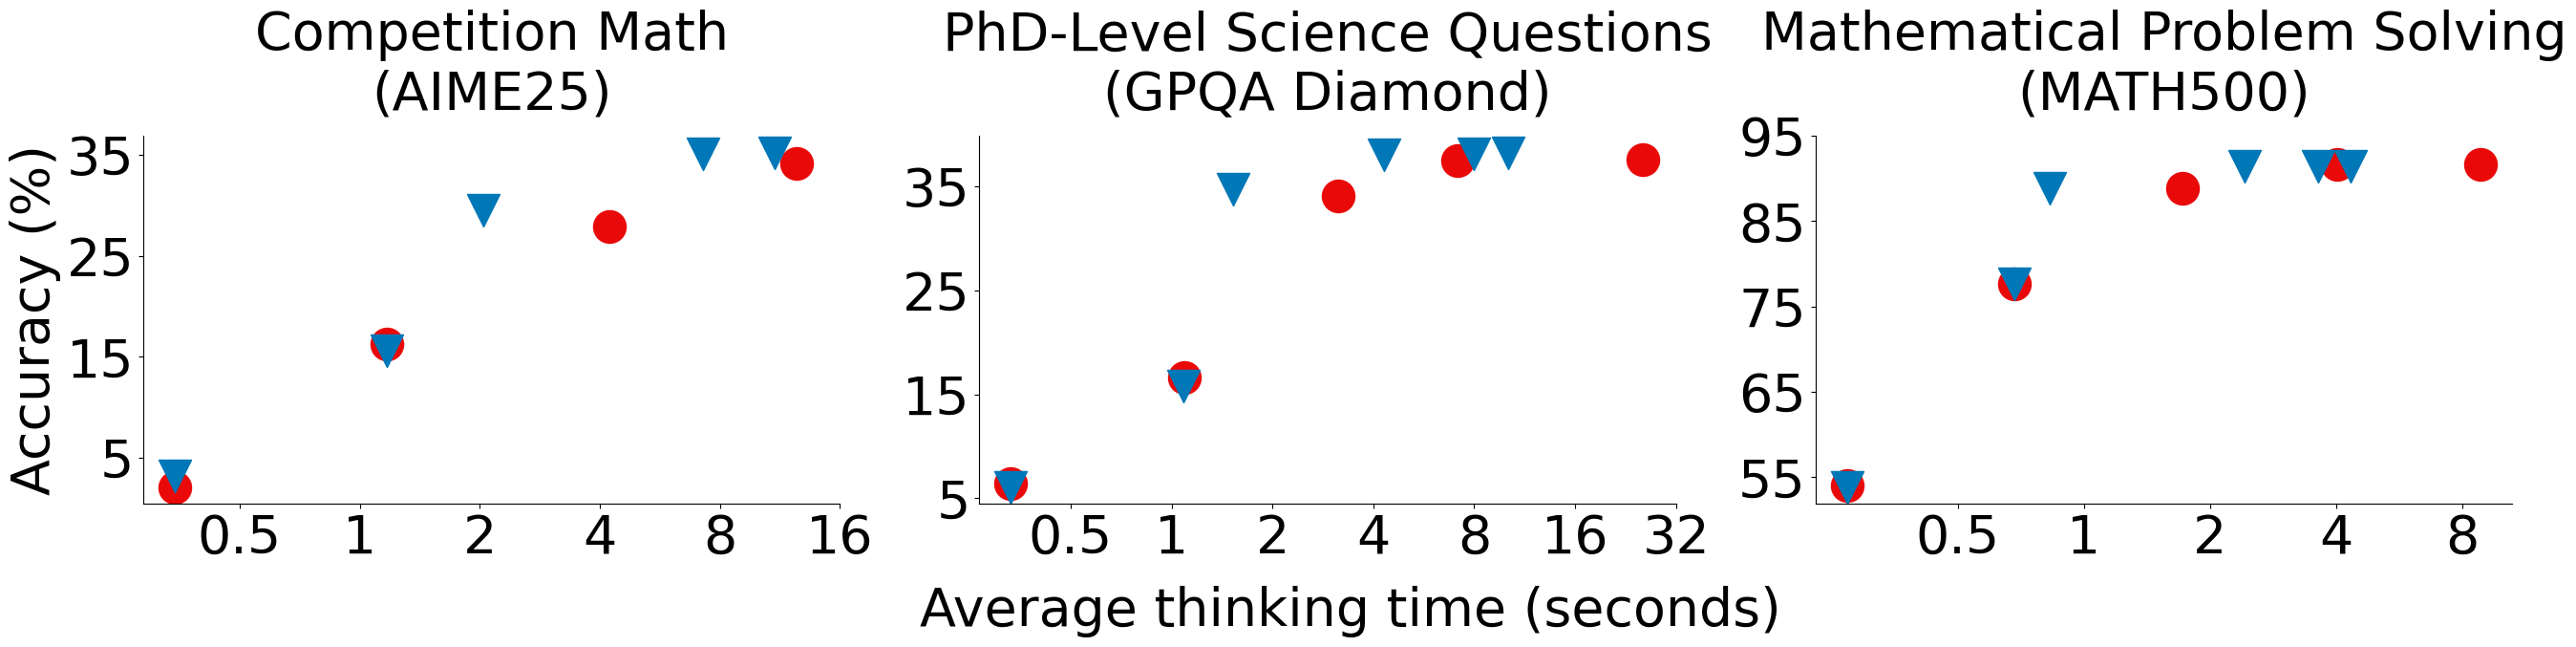

In [36]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE = 40#36
LINEWIDTH = 7
MARKERSIZE = 40
DASHES=(2, 1)
MAX_LENS = [
#    2048,
    4096,
    8192,
    16384,
    32768,
    65536,
    131072,
    262144,
    524288,
]

# Create the plot
fig, axes = plt.subplots(figsize=(32, 5), ncols=3)

### AIME24 ###
ax = axes[0]

# Data points
x_vals = [(qwen_swf16384['results']['aime25_nofigures_tok524288_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['SW']['16384']) for l in MAX_LENS]
y_vals = [qwen_swf16384['results']['aime25_nofigures_tok524288_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Prefix Sliding", color=OUR_COLOR, s=MARKERSIZE*15, zorder=2, marker='v')

x_vals = [(qwen_full['results']['aime25_nofigures_tok131072_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['Full']) for l in MAX_LENS[:-2]]
y_vals = [qwen_full['results']['aime25_nofigures_tok131072_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS[:-2]]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Full", color=FULL_ATTN_COLOR, s=MARKERSIZE*15, zorder=1)

x_ticks = [0.5, 1, 2, 4, 8, 16]
x_log = [np.log2(x) for x in x_ticks]
#x_log = x_ticks
ax.set_xticks(x_log, x_ticks, fontsize=FONTSIZE)

# a, b = ax.get_xlim()
ax.set_yticks(ax.get_yticks()[1::2], [int(x) for x in ax.get_yticks()[1::2]], fontsize=FONTSIZE)
# ax.set_xlim(np.log2(400), np.log2(8000))

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylabel("Accuracy (%)", fontsize=FONTSIZE)
ax.set_title("Competition Math\n(AIME25)", fontsize=FONTSIZE, pad=20)

### GPQA ###
ax = axes[1]

x_vals = [(qwen_swf16384_gpqa['results']['gpqa_diamond_openai_tok524288_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['SW']['16384']) for l in MAX_LENS]
y_vals = [qwen_swf16384_gpqa['results']['gpqa_diamond_openai_tok524288_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Prefix Sliding", color=OUR_COLOR, s=MARKERSIZE*15, zorder=2, marker='v')

x_vals = [(qwen_full_gpqa['results']['gpqa_diamond_openai_tok131072_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['Full']) for l in MAX_LENS[:-2]]
y_vals = [qwen_full_gpqa['results']['gpqa_diamond_openai_tok131072_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS[:-2]]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Full", color=FULL_ATTN_COLOR, s=MARKERSIZE*15, zorder=1)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("PhD-Level Science Questions\n(GPQA Diamond)", fontsize=FONTSIZE, pad=20)

x_ticks = [0.5, 1, 2, 4, 8, 16, 32]
x_log = [np.log2(x) for x in x_ticks]
#x_log = x_ticks
ax.set_xticks(x_log, x_ticks, fontsize=FONTSIZE)
ax.set_yticks(ax.get_yticks()[1::2], [int(x) for x in ax.get_yticks()[1::2]], fontsize=FONTSIZE)

### MATH ###
ax = axes[2]

x_vals = [(qwen_swf16384_math['results']['openai_math_tok524288_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['SW']['16384']) for l in MAX_LENS]
y_vals = [qwen_swf16384_math['results']['openai_math_tok524288_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Prefix Sliding", color=OUR_COLOR, s=MARKERSIZE*15, zorder=2, marker='v')

x_vals = [(qwen_full_math['results']['openai_math_tok262144_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['Full']) for l in MAX_LENS[:-1]]
y_vals = [qwen_full_math['results']['openai_math_tok262144_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS[:-1]]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Full Attention", color=FULL_ATTN_COLOR, s=MARKERSIZE*15, zorder=1)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title("Mathematical Problem Solving\n(MATH500)", fontsize=FONTSIZE, pad=20)

x_ticks = [0.5, 1, 2, 4, 8]
x_log = [np.log2(x) for x in x_ticks]
#x_log = x_ticks
ax.set_xticks(x_log, x_ticks, fontsize=FONTSIZE)
ax.set_yticks(ax.get_yticks()[1::2], [int(x) for x in ax.get_yticks()[1::2]], fontsize=FONTSIZE)

# plt.legend(
#     fontsize=FONTSIZE,
# #    frameon=False
# )

fig.supxlabel("Average thinking time (seconds)", fontsize=FONTSIZE, y=-0.17, x=0.52)

plt.savefig("scaling16384.png", bbox_inches='tight')
plt.savefig("scaling16384.pdf", bbox_inches='tight')
plt.show()

##### Plot: Ablations

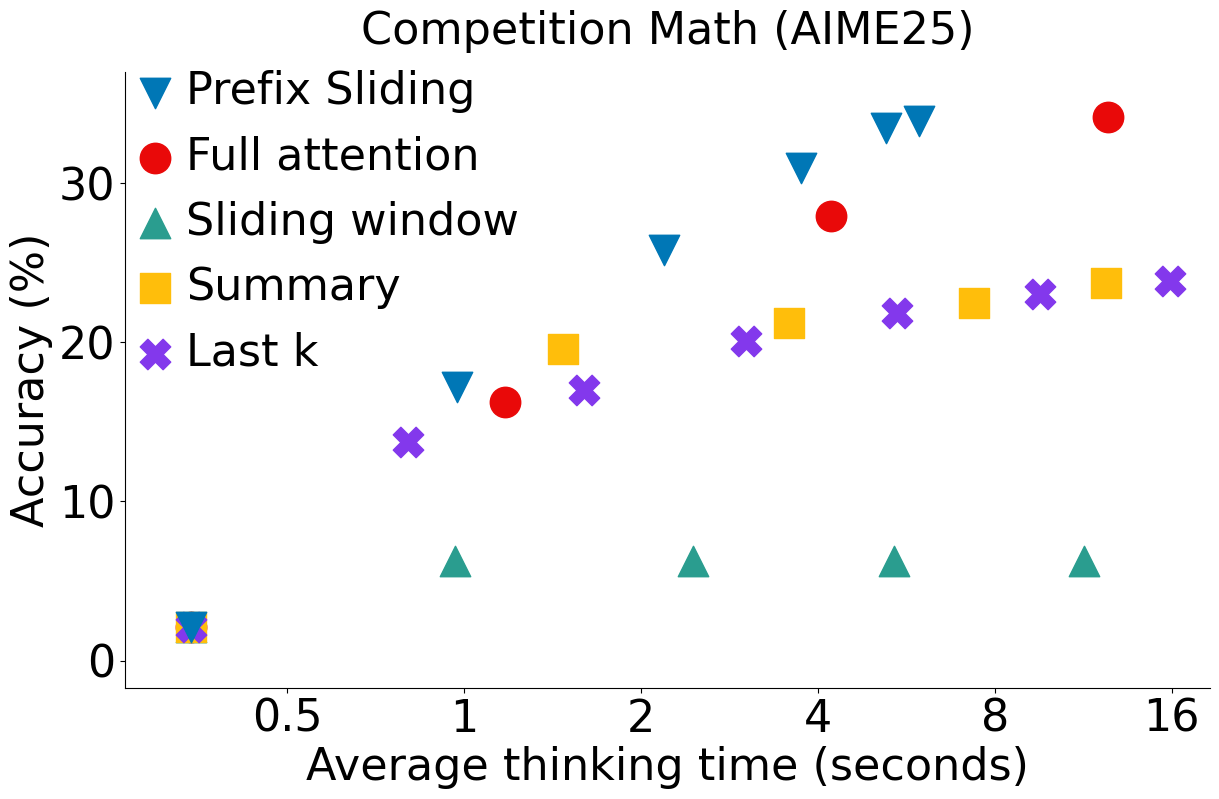

In [37]:
# https://coolors.co/palette/ffbe0b-fb5607-ff006e-8338ec-3a86ff
# https://coolors.co/palette/264653-2a9d8f-e9c46a-f4a261-e76f51
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE = 32
LINEWIDTH = 7
MARKERSIZE = 32
DASHES=(2, 1)
MAX_LENS = [
    2048,
    4096,
    8192,
    16384,
    32768,
    65536,
    131072,
    262144,
]

# Create the plot
fig, axes = plt.subplots(figsize=(14, 8), ncols=1)

### AIME24 ###
ax = axes

# Data points
x_vals = [(qwen_full['results']['aime25_nofigures_tok131072_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['Full']) for l in MAX_LENS[:2]] + [(qwen_swf4096['results']['aime25_nofigures_tok524288_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['SW']['4096']) for l in MAX_LENS[2:-1]]
y_vals =  [qwen_full['results']['aime25_nofigures_tok131072_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS[:2]] + [qwen_swf4096['results']['aime25_nofigures_tok524288_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS[2:-1]]
x_vals_log = [np.log2(x) for x in x_vals]
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Prefix Sliding", color="#0077B6", s=MARKERSIZE*15, zorder=3, marker='v')

x_vals = [(qwen_full['results']['aime25_nofigures_tok131072_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['Full']) for l in MAX_LENS[:-2]]
y_vals = [qwen_full['results']['aime25_nofigures_tok131072_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS[:-2]]
x_vals_log = [np.log2(x) for x in x_vals]
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Full attention", color="#E90909", s=MARKERSIZE*15, zorder=2)

x_vals = [(qwen_full['results']['aime25_nofigures_tok131072_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['Full']) for l in MAX_LENS[:2]] + [(qwen_sw4096['results']['aime25_nofigures_tok524288_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['SWR']['4096']) for l in MAX_LENS[2:]]
y_vals =  [qwen_full['results']['aime25_nofigures_tok131072_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS[:2]] + [qwen_sw4096['results']['aime25_nofigures_tok524288_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS[2:]]
x_vals_log = [np.log2(x) for x in x_vals]
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Sliding window", color="#2A9D8F", s=MARKERSIZE*15, zorder=2, marker='^')

x_vals = [(qwen_full['results']['aime25_nofigures_tok131072_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['Full']) for l in MAX_LENS[:2]] + [(qwen_w4096s256['results']['aime25_nofigures_tok262144_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['Summary']['4096']) for l in MAX_LENS[2:]]
y_vals =  [qwen_full['results']['aime25_nofigures_tok131072_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS[:2]] + [qwen_w4096s256['results']['aime25_nofigures_tok262144_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS[2:]]
x_vals_log = [np.log2(x) for x in x_vals]
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Summary", color="#FFBE0B", s=MARKERSIZE*15, zorder=2, marker='s')

x_vals = [(qwen_full['results']['aime25_nofigures_tok131072_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['Full']) for l in MAX_LENS[:2]] + [(qwen_w4096k256['results']['aime25_nofigures_tok262144_agg64'][f'tok@{l}@64,all'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['Lastk']['4096']) for l in MAX_LENS[2:]]
y_vals =  [qwen_full['results']['aime25_nofigures_tok131072_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS[:2]] + [qwen_w4096k256['results']['aime25_nofigures_tok262144_agg64'][f'avg@{l}@64,all'] for l in MAX_LENS[2:]]
x_vals_log = [np.log2(x) for x in x_vals]
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Last k", color="#8338EC", s=MARKERSIZE*15, zorder=2, marker='X')


x_ticks = [0.1, 0.5, 1, 2, 4, 8, 16]
x_log = [np.log2(x) for x in x_ticks]
ax.set_xticks(x_log, x_ticks, fontsize=FONTSIZE)

a, b = ax.get_xlim()
ax.set_xlim(a+1.6, b - 1.8)
ax.set_yticks(ax.get_yticks()[1::2], [int(x) for x in ax.get_yticks()[1::2]], fontsize=FONTSIZE)

a, b = ax.get_ylim()
ax.set_ylim(a, b - 3)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel("Average thinking time (seconds)", fontsize=FONTSIZE)#
ax.set_ylabel("Accuracy (%)", fontsize=FONTSIZE)
ax.set_title("Competition Math (AIME25)", fontsize=FONTSIZE, pad=20)

plt.legend(
    fontsize=FONTSIZE,
    frameon=False,
    handletextpad=-0.3,
    loc=(-0.03,0.48)
)

plt.savefig("scaling.png", bbox_inches='tight')
plt.savefig("scaling.pdf", bbox_inches='tight')
plt.show()


##### Plot: Healthbench

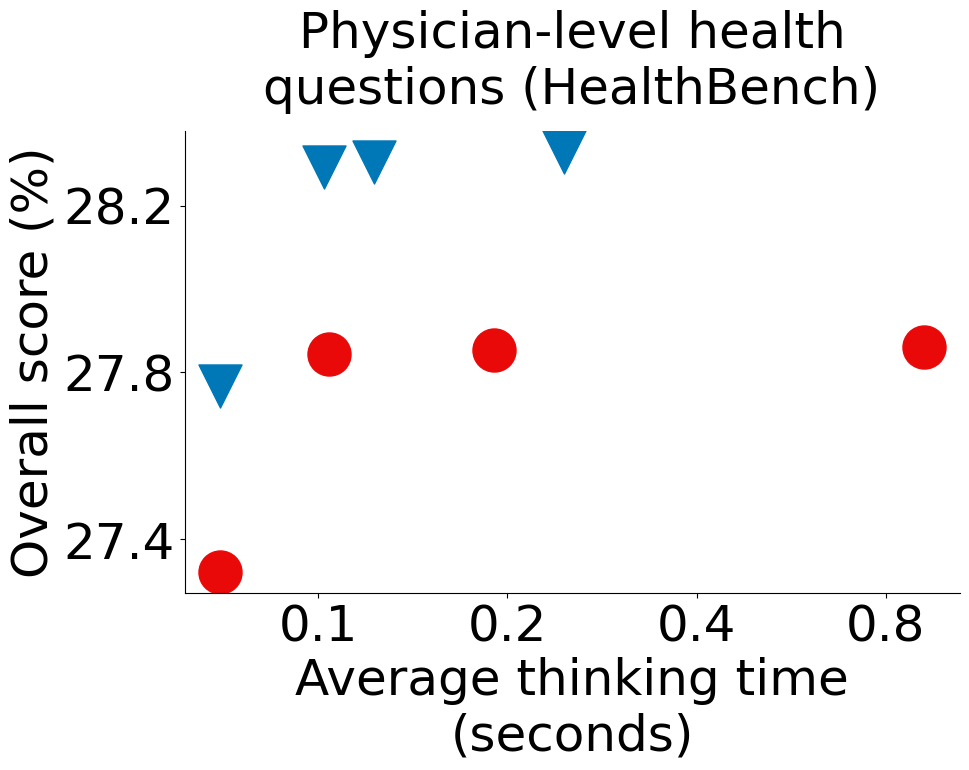

In [38]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE = 36
LINEWIDTH = 7
MARKERSIZE = 64
DASHES=(2, 1)
MAX_LENS = [
#    1024,
    2048,
    4096,
    8192,
    16384,
    32768,
    65536,
    131072,
    262144,
]

# https://coolors.co/palette/03045e-0077b6-00b4d8-90e0ef-caf0f8
BASE_COLOR = "red" # qwen purple
OUR_COLOR = "#0077B6"

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6), ncols=1)

# Data points
x_vals = [(qwen_swf2048_health['results']['healthbench_tok262144'][f'tok@{l}@1,none'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['SW']['2048']) for l in MAX_LENS]
y_vals = [qwen_swf2048_health['results']['healthbench_tok262144'][f'exact_match@{l},none'] for l in MAX_LENS]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Prefix Sliding", color=OUR_COLOR, s=MARKERSIZE*15, zorder=2, marker='v')

x_vals = [(qwen_full_health['results']['healthbench_tok32768'][f'tok@{l}@1,none'] / results['results']['Qwen/Qwen3-1.7B'][str(l)]['Full']) for l in MAX_LENS[:-3]]
y_vals = [qwen_full_health['results']['healthbench_tok32768'][f'exact_match@{l},none'] for l in MAX_LENS[:-3]]
y_vals, x_vals = dedupe_pair(y_vals, x_vals)
x_vals_log = [np.log2(x) for x in x_vals]
#x_vals_log = x_vals
y_vals_scaled = [y * 100 for y in y_vals]
ax.scatter(x_vals_log, y_vals_scaled, label="Full Attention", color=FULL_ATTN_COLOR, s=MARKERSIZE*15, zorder=1)

x_ticks = [0.1, 0.2, 0.4, 0.8]
x_log = [np.log2(x) for x in x_ticks]
#x_log = x_ticks
ax.set_xticks(x_log, x_ticks, fontsize=FONTSIZE)

# a, b = ax.get_xlim()
ax.set_yticks(ax.get_yticks()[1::2], [round(x,1) for x in ax.get_yticks()[1::2]], fontsize=FONTSIZE)
# ax.set_yticks(ax.get_yticks()[1::2], [int(x) for x in ax.get_yticks()[1::2]], fontsize=FONTSIZE)
# ax.set_xlim(np.log2(400), np.log2(8000))

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel("Average thinking time\n(seconds)", fontsize=FONTSIZE)
ax.set_ylabel("Overall score (%)", fontsize=FONTSIZE)
ax.set_title("Physician-level health\nquestions (HealthBench)", fontsize=FONTSIZE, pad=20)

# Reorder
# handles, labels = ax.get_legend_handles_labels()
# order = ["Sliding", "Full"]

# plt.legend(
#     fontsize=FONTSIZE,
#     loc="lower right",
# #    frameon=False
# )

plt.savefig("healthbench.png", bbox_inches='tight')
plt.savefig("healthbench.pdf", bbox_inches='tight')
plt.show()

##### Plot: RL

In [39]:
from google.colab import userdata
import wandb
wandb.login(key=userdata.get('WANDB_MAIN'))
api = wandb.Api()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


In [40]:
!rm -rf *pkl

In [41]:
# Not doing in W&B as
# 1) doesnt fit template/style of other plots
# 2) cannot change order of lines i.e. which one is on top

import os
import pickle

def avg_mmlu(x, keys):
    if len(keys) == 1: return x[keys[0]]
    if "var" in keys[0]:
        return 0.215*x['eval/downstream/mmlu_stem_var_len_norm'] + 0.335*x['eval/downstream/mmlu_humanities_var_len_norm'] + 0.219*x['eval/downstream/mmlu_social_sciences_var_len_norm'] + 0.231*x['eval/downstream/mmlu_other_var_len_norm']
    return 0.215*x['eval/downstream/mmlu_stem_mc_5shot_len_norm'] + 0.335*x['eval/downstream/mmlu_humanities_mc_5shot_len_norm'] + 0.219*x['eval/downstream/mmlu_social_sciences_mc_5shot_len_norm'] + 0.231*x['eval/downstream/mmlu_other_mc_5shot_len_norm']

def get_data(data_dict, suffix, runs=None, sample_every_n=1, wandb="muennighoff/s2/", check_steps=False):
    # Load files if exist
    if os.path.exists("train" + suffix + ".pkl"):
      for k, v in data_dict.items():
        with open(k + suffix + ".pkl", "rb") as f:
          data_dict[k][1] = pickle.load(f)

    else:
      import wandb
      api = wandb.Api()

      for run_id, end_step in runs:
          print("Run ID:", run_id)
          samples = 999_999 // sample_every_n
          run = api.run(f"muennighoff/s2/{run_id}")
          for name, (keys, data) in data_dict.items():
              if check_steps:
                  data += [
                      (x['train/global_step'], avg_mmlu(x, keys)) for x in run.history(samples=samples, keys=keys, x_axis="train/global_step", pandas=False, stream="default") if x['train/global_step'] <= end_step
                  ]
              else:
                  data += [
                      (x['train/global_step'], avg_mmlu(x, keys)) for x in run.history(samples=samples, keys=keys, x_axis="train/global_step", pandas=False, stream="default")
                  ]
      # Save to file
      for k, v in data_dict.items():
        with open(k + suffix + ".pkl", "wb") as f:
          pickle.dump(v[1], f)

us_runs = [
    ("stnu9nzy", 200),
]

full_runs = [
    ("rtavhgbh", 200),
]

DATA_US = {
    "train": [["train/reward"], []],
    "train_len": [["train/completions/max_length_full"], []],
}

DATA_FULL = {
    "train": [["train/reward"], []],
    "train_len": [["train/completions/max_length"], []],
}

get_data(DATA_US, "_us", us_runs, check_steps=True)
get_data(DATA_FULL, "_full", full_runs, check_steps=True)

print(len(DATA_US["train"][1]))

Run ID: stnu9nzy
Run ID: rtavhgbh
200


In [42]:
from typing import List
import os

# https://stackoverflow.com/questions/42281844/what-is-the-mathematics-behind-the-smoothing-parameter-in-tensorboards-scalar
def smooth(scalars: List[float], weight: float) -> List[float]:  # Weight between 0 and 1
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor the last smoothed value

    return smoothed

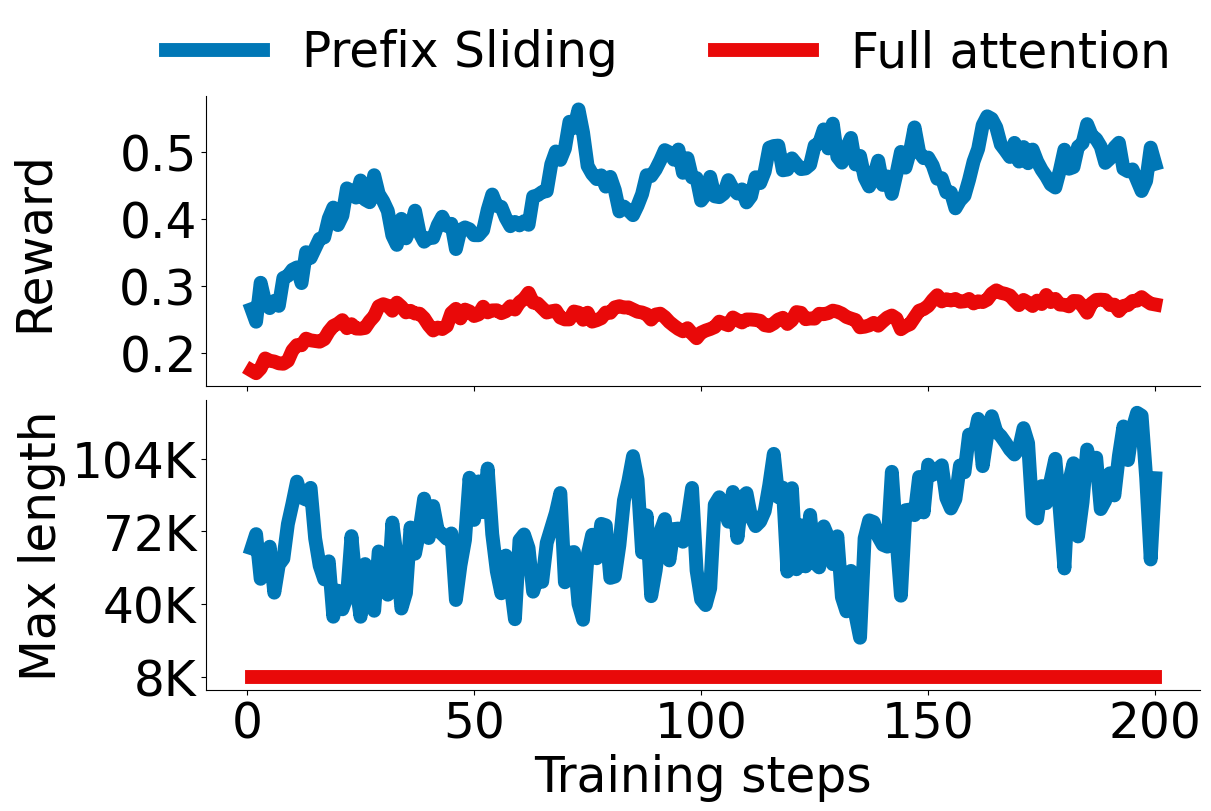

In [43]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE = 35

fig, axes = plt.subplots(figsize=(12, 8), ncols=1, nrows=2, sharex=True, layout='constrained')

titles = [
    "During Reinforcement Learning",
    "Reward",
    "Generation length",
]

ylabels = [
    "Reward\n",
    "Max length",
]

colors = [
    "#F0539B",
    "#43C5E0",
    "#2E3168",
    "#FDBE15",
]

data = [
  (DATA_US["train"], DATA_FULL["train"]),
  (DATA_US["train_len"], DATA_FULL["train_len"]),
]

for i, ax in enumerate(axes):
    mult = 1 # 100 if i >=3 else 1
    if i == 0:
        # ax.plot(
        #     [x[0] for x in data[i][1][1]],
        #     [x[1]*mult for x in data[i][1][1]],
        #     linewidth=12.0,
        #     color=FULL_ATTN_COLOR,
        #     label="Full Attention",
        #     alpha=0.5,
        # )
        # ax.plot(
        #     [x[0] for x in data[i][0][1]],
        #     [x[1]*mult for x in data[i][0][1]],
        #     linewidth=12.0,
        #     color=OUR_COLOR,
        #     label="MethodName",
        #     alpha=0.5,
        # )
        ax.plot(
            [x[0] for x in data[i][1][1]],
            smooth([x[1]*mult for x in data[i][1][1]], weight=0.9),
            linewidth=10.0,
            color=FULL_ATTN_COLOR,
            label="Full attention",
        )
        ax.plot(
            [x[0] for x in data[i][0][1]],
            smooth([x[1]*mult for x in data[i][0][1]], weight=0.9),
            linewidth=10.0,
            color=OUR_COLOR,
            label="Prefix Sliding",
        )
    else:
        # ax.plot(
        #     [x[0] for x in data[i][1][1]],
        #     [x[1]*mult for x in data[i][1][1]],
        #     #[x[1]*mult for x in data[i][1][1]],
        #     #[np.log2(x) for x in smooth([x[1]*mult for x in data[i][1][1]], weight=0.9)],
        #     #np.log2(smooth([x[1]*mult for x in data[i][1][1]], weight=0.9)),
        #     linewidth=12.0,
        #     color=FULL_ATTN_COLOR,
        #     label="Full Attention",
        #     alpha=0.5,
        # )
        # ax.plot(
        #     [x[0] for x in data[i][0][1]],
        #     [x[1]*mult for x in data[i][0][1]],
        #     #[x[1]*mult for x in data[i][0][1]],
        #     #[np.log2(x) for x in smooth([x[1]*mult for x in data[i][0][1]], weight=0.9)],
        #     #np.log2(smooth([x[1]*mult for x in data[i][0][1]], weight=0.9)),
        #     linewidth=12.0,
        #     color=OUR_COLOR,
        #     label="MethodName",
        #     alpha=0.5
        # )

        ax.plot(
            [x[0] for x in data[i][0][1]],
            smooth([x[1]*mult for x in data[i][0][1]], weight=0.5),
            #[x[1]*mult for x in data[i][0][1]],
            #[np.log2(x) for x in smooth([x[1]*mult for x in data[i][0][1]], weight=0.9)],
            #np.log2(smooth([x[1]*mult for x in data[i][0][1]], weight=0.9)),
            linewidth=10.0,
            color=OUR_COLOR,
            label="Prefix Sliding",
            #alpha=0.5
        )

        ax.plot(
            [x[0] for x in data[i][1][1]],
            smooth([x[1]*mult for x in data[i][1][1]], weight=0.5),
            #[x[1]*mult for x in data[i][1][1]],
            #[np.log2(x) for x in smooth([x[1]*mult for x in data[i][1][1]], weight=0.9)],
            #np.log2(smooth([x[1]*mult for x in data[i][1][1]], weight=0.9)),
            linewidth=10.0,
            color=FULL_ATTN_COLOR,
            label="Full attention",
            #alpha=0.5
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(axis='both', which='major', labelsize=FONTSIZE)

    # if i < 3:
    #   ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    # elif i >= 3:
    #   ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.0f'))

    # x_ticks = [10, 40, 70, 100, 130]
    # # Transform billion tokens to steps
    # x_ticks_loc = [x * 1e9 / TOKENS_PER_STEP for x in x_ticks]
    # ax.set_xticks(x_ticks_loc, x_ticks)

    # if i == 0:
    #     a, b = ax.get_ylim()
    #     ax.set_ylim([2.2, 4.2])

    if i == 0:
#        ax.set_title(titles[i], fontsize=FONTSIZE, fontweight='bold')
        # legend
        handles, labels = ax.get_legend_handles_labels()
        order = [1, 0]
        ax.legend(
            [handles[idx] for idx in order],
            [labels[idx] for idx in order],
            fontsize=FONTSIZE,
            frameon=False,
            ncol=2,
            loc=(-0.06,1)
        )
        y_ticks_str = ["0.2", "0.3", "0.4", "0.5"]
        y_ticks_float = [0.2, 0.3, 0.4, 0.5]
        ax.set_yticks(y_ticks_float, y_ticks_str, fontsize=FONTSIZE)

    elif i == 1:
        y_ticks_str = ["8K", "16K", "32K", "64K", "128K", "256K"]
        # y_ticks_float = [8000, 16000, 32000, 64000, 128000, 256000]
        # y_ticks_float_log = [np.log2(x) for x in y_ticks_float]
        # ax.set_yticks(y_ticks_float_log, y_ticks_str, fontsize=FONTSIZE)

        y_ticks_str = ["8K", "40K", "72K", "104K"]
        y_ticks_float = [8000, 40000, 72000, 104000]
        ax.set_yticks(y_ticks_float, y_ticks_str, fontsize=FONTSIZE)
        ax.set_xlabel('Training steps', fontsize=FONTSIZE)#, fontweight='bold')

    ax.set_ylabel(ylabels[i], fontsize=FONTSIZE)

# plt.legend(
#     fontsize=FONTSIZE,
#     frameon=False,
#     ncol=2,
#     loc=(0,1),
# )


#fig.supylabel('Reward', fontsize=FONTSIZE, fontweight='bold')
#fig.supxlabel('Training Steps', fontsize=FONTSIZE)#, fontweight='bold')

plt.savefig('rl.png', dpi=300, bbox_inches='tight')
plt.savefig('rl.pdf', dpi=300, bbox_inches='tight')
plt.show()
